# Run this first !
Ensures correct libraries and imports data

In [351]:
# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

# Updated with new data as of 2026-09-30
utt = loading.load(DATA, "all_utterances.csv", "2026-09-30")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-30")
met = loading.load(DATA, "all_metrics.csv", "2026-09-30")

print(utt.shape, sent.shape, met.shape)
sent.head()
#data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13', '2026-09-23', '2026-09-30']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  2570 rows
loaded all_sentences.csv  19092 rows
loaded all_metrics.csv  1021 rows
(2570, 11) (19092, 12) (1021, 6)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,1,"Good morning, ladies and gentlemen."
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,2,Welcome to JPMorgan Chase's First Quarter 2022...
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,3,This call is being recorded.
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,4,Your line will be muted for the duration of th...
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,5,We will now go live to the presentation.


In [352]:
# Start timer
import time
start_time = time.time()

# Using John's changes to the exported data

## Link to download data will need to change

In [353]:
# Import structured sentences file
str_sent = pd.read_csv("/Users/rdrobinson/Cambridge/boe-financial-analysis/notebooks/rachel/All_in_one/revised_structured_sentences.csv")
data = str_sent.copy()

In [354]:
# Remove rows where is_filler_sentence = True
data = data[data['is_filler_sentence'] != True]

In [355]:
data.head()

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,utterance_id,sentence_raw,is_filler_sentence
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,2,Welcome to JPMorgan Chase's First Quarter 2022...,0,Welcome to JPMorgan Chase's First Quarter 2022...,False
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,3,This call is being recorded.,0,This call is being recorded.,False
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,4,Your line will be muted for the duration of th...,0,Your line will be muted for the duration of th...,False
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,5,We will now go live to the presentation.,0,We will now go live to the presentation.,False
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,7,"At this time, I would like to turn the call ov...",0,"At this time, I would like to turn the call ov...",False


# Sentence tokenisation

### Import ntlk

In [356]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Speaker Names
Need to remove these from the sentences

In [357]:
# Create a list using "speaker_name" column from the dataframe
speaker_names = data["speaker_name"].tolist()
# Reduce list to contain only unique speaker names
speaker_names = list(set(speaker_names))
# Split first and last names of the speakers
speaker_names_split = [name.split() for name in speaker_names]
# remove capital letters from speaker names
speaker_names_split = [[name.lower() for name in sublist] for sublist in speaker_names_split]
speaker_names_split[:10]

[['gerard', 'cassidy'],
 ['sergio', 'p.', 'ermotti'],
 ['scott', 'siefers'],
 ['jim', 'mitchell'],
 ['chris', 'hallam'],
 ['andrew', 'coombs'],
 ['chris', 'kotowski'],
 ['alastair', 'ryan'],
 ['stefan', 'stalmann'],
 ['matt', "o'connor"]]

### Tokenising Function

In [358]:
import re

def expand_contractions(t):
    t = t.replace("’", "'")
    t = re.sub(r"won't", "will not", t)
    t = re.sub(r"can't", "can not", t)
    t = re.sub(r"n't\b", " not", t)
    t = re.sub(r"'(s|re|ve|ll|d|m)\b", "", t)
    return t


In [359]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    #text = re.sub(r'[^a-zA-Z\s]', '', text)
    # in preprocess_text, after text = text.lower():
    text = expand_contractions(text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))

    # Remove speaker names from the text
    speaker_names_flat = [name for sublist in speaker_names_split for name in sublist]

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        # Removed "greeting words" from the line below:
        if word not in stop_words and word.isalpha() and word and word not in speaker_names_flat # Ensure only alphabetic words are kept and remove greeting words and speaker names
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [360]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head(5))

                                            sentence  \
1  Welcome to JPMorgan Chase's First Quarter 2022...   
2                       This call is being recorded.   
3  Your line will be muted for the duration of th...   
4           We will now go live to the presentation.   
6  At this time, I would like to turn the call ov...   

                                        cleaned_text  
1  [welcome, jpmorgan, chase, first, quarter, ear...  
2                                   [call, recorded]  
3                      [line, muted, duration, call]  
4                           [go, live, presentation]  
6  [time, would, like, turn, call, jpmorgan, chas...  


In [361]:
# Count number of rows for total sentences
print("The total number of sentences for both banks is:", data.shape[0])


The total number of sentences for both banks is: 16513


# Choose Bank
Amend the commented section to include the bank of choice. Default is set as UBS

In [362]:
# Choose bank name - either UBS or JPM for this work
bank_name = 'UBS'

In [363]:
# Create folder for bank_name specific sentiment classification results
import os

results_folder = f"results_{bank_name}"
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

In [364]:
# Create dataframe with bank = '***' (replace with bank of choice)
data = data[data['bank'] == bank_name].copy()
print(data.shape)
data.head(2)

(8217, 16)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,utterance_id,sentence_raw,is_filler_sentence,cleaned_text
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,1,Thank you Sarah.,0,Thank you Sarah.,False,[thank]
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,3,The first quarter of 2022 was dominated by ext...,0,The first quarter of 2022 was dominated by ext...,False,"[first, quarter, dominated, extraordinary, geo..."


In [365]:
# Count number of rows for total sentences for chosen bank
print(f"The total number of sentences for {bank_name} is:", data.shape[0])

The total number of sentences for UBS is: 8217


<Figure size 1000x600 with 0 Axes>

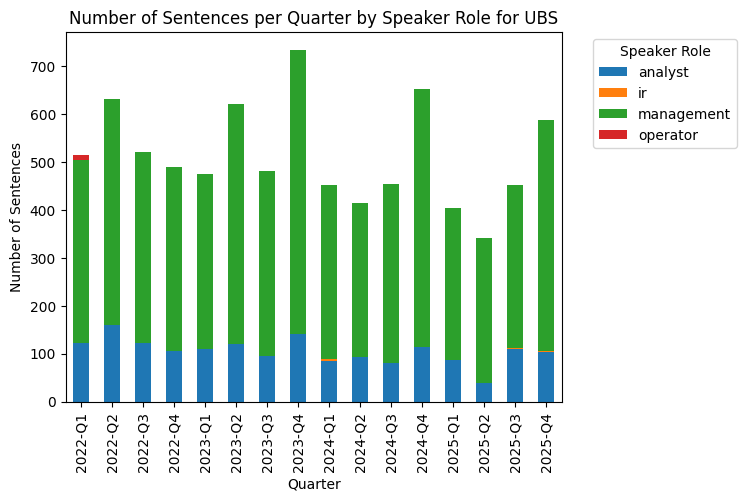

In [366]:
# Plot number of sentences for each quarter, split by speaker_role as a stacked plot
# This plot shows the distribution of sentences per quarter, broken down by speaker role.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
data.groupby(['quarter', 'speaker_role'])['sentence'].count().unstack().plot(kind='bar', stacked=True)
# Include bank name in the title
plt.title(f'Number of Sentences per Quarter by Speaker Role for {bank_name}')
plt.xlabel('Quarter')
plt.ylabel('Number of Sentences')
# Move legend outside the plot
plt.legend(title='Speaker Role', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



Note the call date for Q4 2022 was in January 2023, and also the Q1 2023 call date was in April 2023, after the announcement to acquire Credit Suisse on the 19th March 2023.

## Split by Section to check speakers
Are the same speakers who give the presentation, the same as those who are involved in the Q&A. If so then their language can be directly compared in both

In [367]:
# List all speaker names that are speaker_role = management and section = 'Q&A'
management_qa_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'qa')]['speaker_name'].unique()
print(management_qa_speakers)

['Ralph Hamers' 'Kirt Gardner' 'Sarah Youngwood' 'Sergio P. Ermotti'
 'Todd Tuckner']


In [368]:
# List all speaker names that are speaker_role = management and section = "prepared"
management_prepared_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'prepared')]['speaker_name'].unique()
print(management_prepared_speakers)

['Ralph Hamers' 'Kirt Gardner' 'Sarah Youngwood' 'Sergio P. Ermotti'
 'Todd Tuckner']


All of the speakers listed as Management in the Q&A session match those in the presentation section and therefore their responses during a scripted presentation vs an open Q&A session can be investigated.

# Bert Emotion: All sections

Truncation = True means only 512 tokens (350 -400 words) are kept. Anything longer is ignored. Also output contains top_k = None so that the scores for all the emotions are retained to allow comparison later on

## Fix colours for emotions

In [369]:
# Fix colours of bars to emotion categories to be used in sns and matplotlib
emotion_palette = {
    'joy': 'darkorange',
    'anger': 'red',
    'sadness': 'dodgerblue',
    'fear': 'purple',
    'surprise': 'green',
    'disgust': 'brown',
    'love': 'deeppink'
}

## Build pipeline

In [370]:
# Conduct Bert Emotion analysis on cleaned sentences from presentation section (UBS)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    data["sentence"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7636.44it/s]


## Run the model

In [371]:
# Run the model and keep all emotion scores
basic_emotion = emotion_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
emotion_rows = []
for result in basic_emotion:
    if isinstance(result, list):
        emotion_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        emotion_rows.append({result["label"]: result["score"]})
    else:
        emotion_rows.append({})

# Add the top emotion and score to the dataframe
data["main_emotion"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in emotion_rows
]
data["main_emotion_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in emotion_rows
]

# Add all emotion columns as separate numeric columns
for emotion in ["anger", "joy", "fear", "sadness", "love", "surprise"]:
    data[emotion] = [row.get(emotion, 0.0) for row in emotion_rows]

In [372]:
data.head(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,is_filler_sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,False,[thank],joy,0.925392,0.000855,0.925392,0.000273,0.000963,0.071917,0.000601
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,False,"[first, quarter, dominated, extraordinary, geo...",joy,0.983220,0.002036,0.983220,0.005678,0.001843,0.000777,0.006446


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

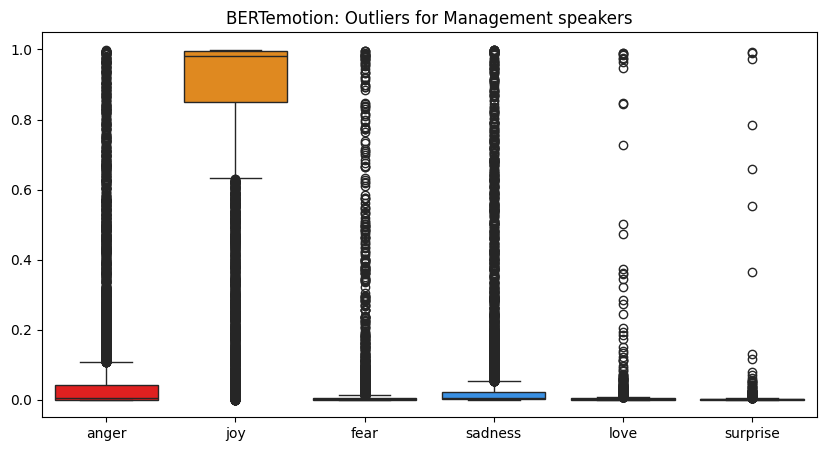

In [373]:
# Look for outliers in emotions of ubs_data where speaker_role = "management"
import seaborn as sns

# Visualize outliers of last 6 columns (emotions) using boxplots
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -6:], palette=emotion_palette)
plt.title("BERTemotion: Outliers for Management speakers")
plt.show()

## Calculate quarterly emotion values (Management not Analyst)

In [374]:
# Create dataframe to calculate median and standard deviation of every emotion every quarter (UBS)
emotion_stats = data.groupby(["quarter", "main_emotion", "speaker_role","section"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
emotion_stats = emotion_stats[emotion_stats['speaker_role'] != 'analyst']
emotion_stats.head(10)   

,quarter,main_emotion,speaker_role,section,median_score,std_score
1,2022-Q1,anger,management,prepared,0.679569,0.137402
2,2022-Q1,anger,management,qa,0.748629,0.168560
3,2022-Q1,anger,operator,qa,0.902614,0.095529
5,2022-Q1,fear,management,prepared,0.980526,0.206265
6,2022-Q1,fear,management,qa,0.812992,0.181987
8,2022-Q1,joy,management,prepared,0.984133,0.112707
9,2022-Q1,joy,management,qa,0.982657,0.108464
10,2022-Q1,joy,operator,qa,0.637023,0.000000
12,2022-Q1,sadness,management,prepared,0.537200,0.188867
13,2022-Q1,sadness,management,qa,0.553920,0.196605


In [375]:
# Calculate max and mean values for std_score
emotion_std_max = emotion_stats.groupby('main_emotion')['std_score'].max()
emotion_std_mean = emotion_stats.groupby('main_emotion')['std_score'].mean()
print("Max std_score per emotion:")
print(emotion_std_max)
print("\nMean std_score per emotion:")
print(emotion_std_mean)

Max std_score per emotion:
main_emotion
anger       0.220862
fear        0.342598
joy         0.138340
love        0.253433
sadness     0.363638
surprise    0.088025
Name: std_score, dtype: float64

Mean std_score per emotion:
main_emotion
anger       0.154282
fear        0.136863
joy         0.101040
love        0.030072
sadness     0.173359
surprise    0.017605
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections for all emotions

In [376]:
# Calculate differences between prepared and QA emotion scores for UBS management if NaN use zero
diff_emotion_stats = emotion_stats.pivot_table(index=['quarter', 'main_emotion'], columns='section', values='median_score').reset_index()
diff_emotion_stats = diff_emotion_stats.fillna(0)
diff_emotion_stats['diff'] = diff_emotion_stats['qa'] - diff_emotion_stats['prepared']

In [377]:
# Find max standard deviation from all emotions from emotion_std_max values
all_emotion_std_max = emotion_std_max.max()
print("Value for error bars: ", all_emotion_std_max)

Value for error bars:  0.3636383095783847


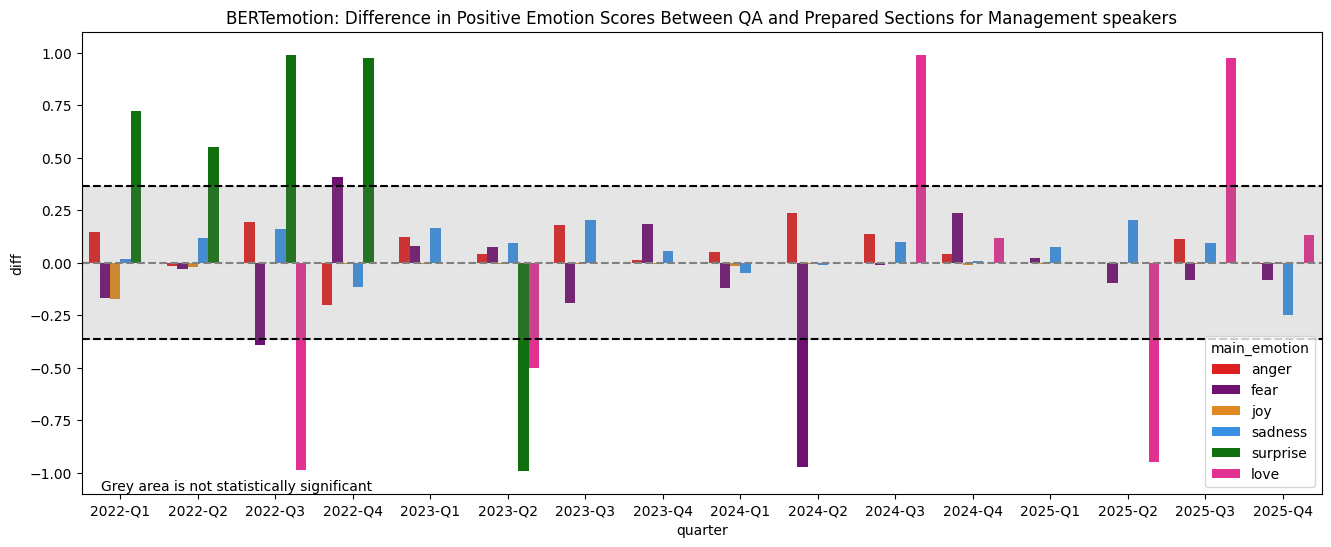

In [378]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.title("Difference in Emotion Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_emotion_std_max, linestyle='--', color='black')
plt.axhline(-all_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_emotion_std_max,
    all_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=-1.1, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/BERT_emotion_differences_{bank_name}.png")

### Merger period Q2 2022 to Q2 2024

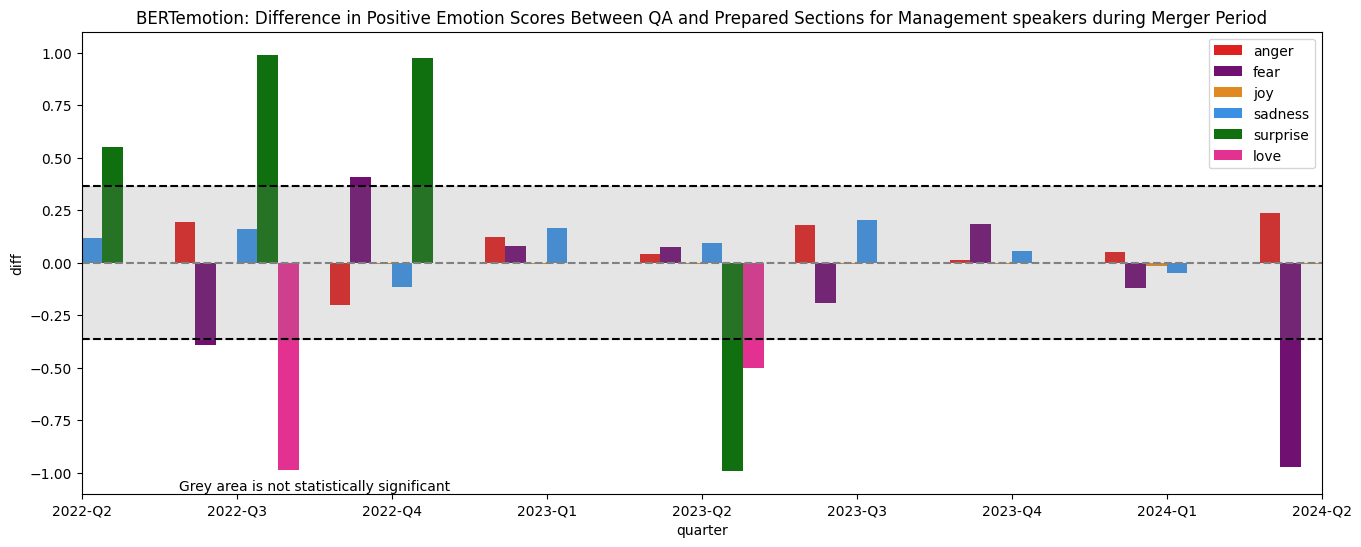

In [379]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.title("Difference in Emotion Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

#Set x-lim to include from 2022-Q2 to 2024-Q2
plt.xlim("2022-Q2", "2024-Q2")
# plot x-line at value of positive emotion standard deviation
plt.axhline(all_emotion_std_max, linestyle='--', color='black')
plt.axhline(-all_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_emotion_std_max,
    all_emotion_std_max,
    color='grey',
    alpha=0.2
)

# move legend to upper right
plt.legend(loc='upper right')
plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers during Merger Period")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=2.5, 
    y=-1.1, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/BERT_emotion_differences_merge_period_{bank_name}.png")

# FinBERT Model

## Fix colours for sentiments

In [380]:
# Fix colours of bars to sentiment categories to be used in sns and matplotlib
sentiment_palette = {
    # For FinBERT model
    'positive': 'darkorange',
    'neutral': 'grey',
    'negative': 'dodgerblue',

    # For FinBERT-Tone model
    'Positive': 'darkorange',
    'Neutral': 'grey',
    'Negative': 'dodgerblue',

    # For FinBERT-Tone model (which also uses capitalized sentiment labels)
    'FBT_Positive': 'darkorange',
    'FBT_Neutral': 'grey',
    'FBT_Negative': 'dodgerblue',

    # For RoBERTa model
    'RBT_positive': 'darkorange',
    'RBT_neutral': 'grey',
    'RBT_negative': 'dodgerblue',
}

## Build pipeline

In [381]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# Load FinBERT model and tokenizer
model_name = "prosusai/finbert"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["sentence"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 61491.98it/s]


## Run the model

In [382]:
# Run the model and keep all sentiment scores
basic_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["main_sentiment"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in sentiment_rows
]
data["main_sentiment_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
for sentiment in ["positive", "negative", "neutral"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]

In [383]:

data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,joy,fear,sadness,love,surprise,main_sentiment,main_sentiment_score,positive,negative,neutral
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,0.925392,0.000273,0.000963,0.071917,0.000601,neutral,0.820914,0.165656,0.013430,0.820914
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,0.983220,0.005678,0.001843,0.000777,0.006446,negative,0.903126,0.018587,0.903126,0.078286
9908,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33598,...,0.035146,0.048541,0.172228,0.003273,0.001086,neutral,0.829264,0.155715,0.015021,0.829264
9909,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33599,...,0.998029,0.000187,0.000404,0.000749,0.000333,positive,0.846276,0.846276,0.008745,0.144979
9910,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33600,...,0.997520,0.000140,0.000715,0.000867,0.000240,neutral,0.535265,0.454572,0.010163,0.535265
9911,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33601,...,0.953995,0.005575,0.006912,0.014856,0.001853,neutral,0.888598,0.090798,0.020604,0.888598
9912,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33602,...,0.981563,0.003214,0.005977,0.003437,0.000901,neutral,0.884369,0.097926,0.017704,0.884369
9913,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33603,...,0.017873,0.010757,0.263420,0.001781,0.001148,positive,0.947000,0.947000,0.018450,0.034550
9914,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33604,...,0.996830,0.000231,0.000863,0.001174,0.000293,positive,0.957479,0.957479,0.018399,0.024122
9915,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33605,...,0.991914,0.000147,0.000710,0.005846,0.000423,positive,0.901878,0.901878,0.011221,0.086901


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

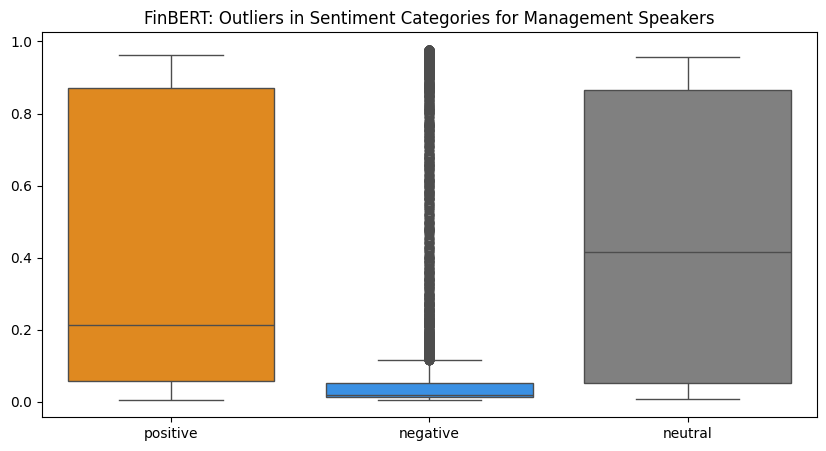

In [384]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -3:], palette=sentiment_palette)
plt.title("FinBERT: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [385]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
sentiment_stats = data.groupby(["quarter", "main_sentiment", "speaker_role","section"]).agg(
    median_score=("main_sentiment_score", "median"),
    std_score=("main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
sentiment_stats = sentiment_stats[sentiment_stats['speaker_role'] != 'analyst']
sentiment_stats.head(10)   

,quarter,main_sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,negative,management,prepared,0.967833,0.042467
2,2022-Q1,negative,management,qa,0.751044,0.123123
4,2022-Q1,neutral,management,prepared,0.771331,0.143010
5,2022-Q1,neutral,management,qa,0.864304,0.115254
6,2022-Q1,neutral,operator,qa,0.916947,0.008224
8,2022-Q1,positive,management,prepared,0.918983,0.144037
9,2022-Q1,positive,management,qa,0.799915,0.154537
11,2022-Q2,negative,management,prepared,0.959253,0.109619
12,2022-Q2,negative,management,qa,0.837973,0.152687
14,2022-Q2,neutral,management,prepared,0.861665,0.128108


In [386]:
# Calculate max and mean values for std_score for sentiments
sentiment_std_max = sentiment_stats.groupby('main_sentiment')['std_score'].max()
sentiment_std_mean = sentiment_stats.groupby('main_sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(sentiment_std_max)
print("\nMean std_score per sentiment:")
print(sentiment_std_mean)

Max std_score per sentiment:
main_sentiment
negative    0.198102
neutral     0.181886
positive    0.156743
Name: std_score, dtype: float64

Mean std_score per sentiment:
main_sentiment
negative    0.146187
neutral     0.113600
positive    0.122759
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [387]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_sentiment_stats = sentiment_stats.pivot_table(index=['quarter', 'main_sentiment'], columns='section', values='median_score').reset_index()
diff_sentiment_stats = diff_sentiment_stats.fillna(0)
diff_sentiment_stats['diff'] = diff_sentiment_stats['qa'] - diff_sentiment_stats['prepared']

In [388]:
diff_sentiment_stats.head(10)

section,quarter,main_sentiment,prepared,qa,diff
0,2022-Q1,negative,0.967833,0.751044,-0.216789
1,2022-Q1,neutral,0.771331,0.890626,0.119294
2,2022-Q1,positive,0.918983,0.799915,-0.119067
3,2022-Q2,negative,0.959253,0.837973,-0.121280
4,2022-Q2,neutral,0.861665,0.878741,0.017076
5,2022-Q2,positive,0.930720,0.818186,-0.112534
6,2022-Q3,negative,0.959170,0.787422,-0.171748
7,2022-Q3,neutral,0.905944,0.884504,-0.021439
8,2022-Q3,positive,0.927675,0.785745,-0.141929
9,2022-Q4,negative,0.955711,0.878700,-0.077011


In [389]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_sentiment_std_max = sentiment_std_max.max()
print("Value for error bars: ", all_sentiment_std_max)

Value for error bars:  0.19810173219750254


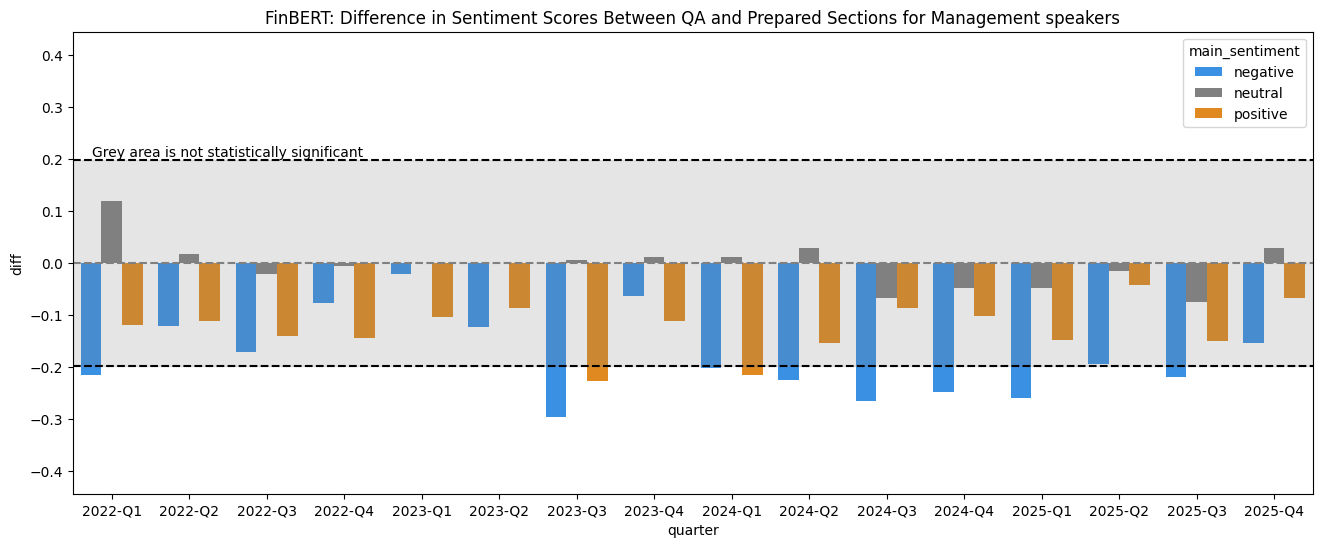

In [390]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_sentiment_std_max,
    all_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/FinBERT_sentiment_differences_{bank_name}.png")

### Merger period Q2 2022 to Q2 2024

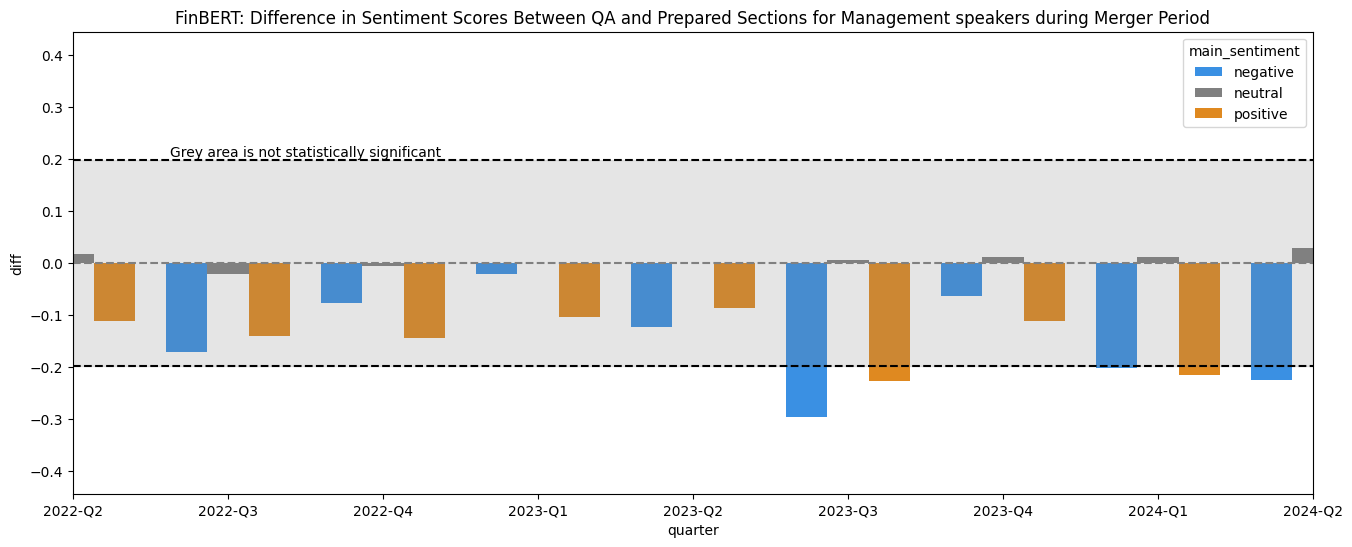

In [391]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

# set x-lim to include from 2022-Q2 to 2024-Q2
plt.xlim("2022-Q2", "2024-Q2")
plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_sentiment_std_max,
    all_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers during Merger Period")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=2.5, 
    y=all_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/FinBERT_sentiment_differences_merge_period_{bank_name}.png")

# Compare FinBERT and BERTemotion

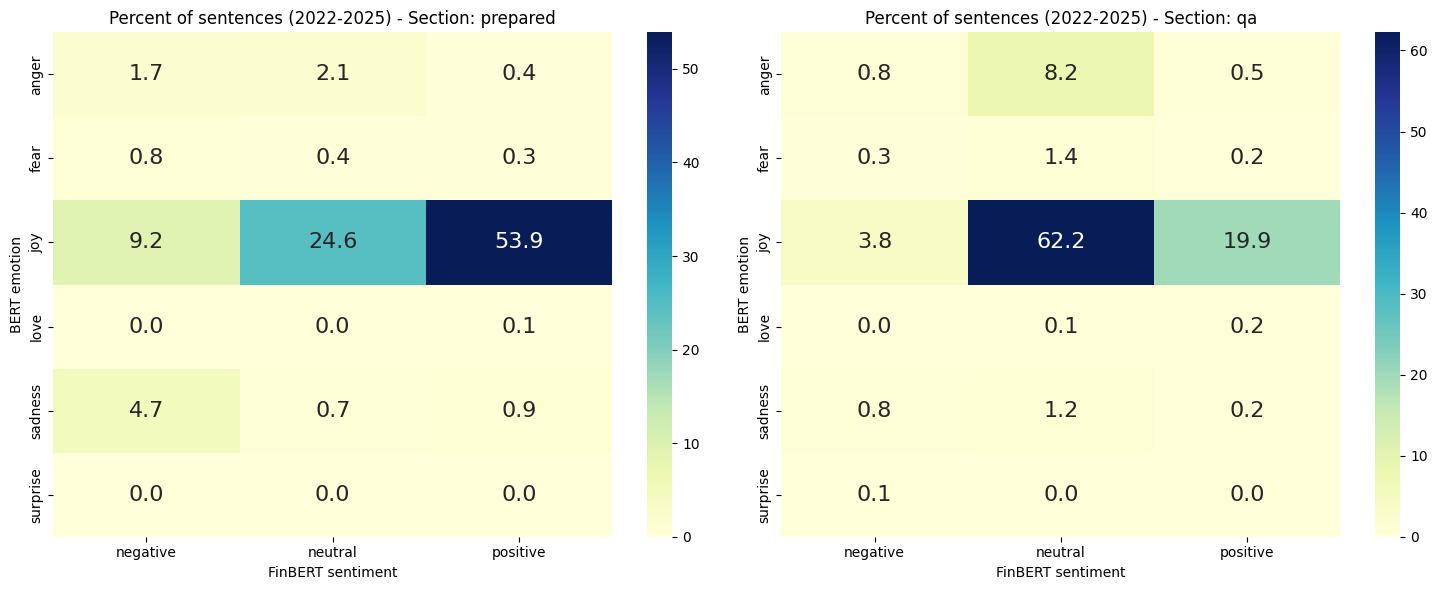

In [392]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# Save data in dataframe for final comparison with other heatmaps
comparison_data = []
for section in sections[:2]:
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    comparison_data.append((section, heatmap_data))
comparison_df1 = pd.concat([df for section, df in comparison_data], keys=[section for section, df in comparison_data])   

# Save figure in bank folder
fig.savefig(f'{results_folder}/BERT_emotion_vs_FinBERT_{bank_name}.png')
plt.show()

# FinBERT-Tone Model

## Build pipeline

In [393]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# Load FinBERT model and tokenizer
model_name = "yiyanghkust/finbert-tone"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["sentence"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 61581.82it/s]


## Run the model

In [394]:
# Run the model and keep all sentiment scores
basic_FBT_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_FBT_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["FBT_Main_Sentiment"] = [
    max(row, key=row.get, default="Neutral") if row else "Neutral"
    for row in sentiment_rows
]
data["FBT_Main_Sentiment_Score"] = [
    row.get(max(row, key=row.get, default="Neutral"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
# NOTE: FinBERT-Tone requires capital letters for the sentiment labels
for sentiment in ["Positive", "Negative", "Neutral"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]

In [395]:
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,main_sentiment,main_sentiment_score,positive,negative,neutral,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,Positive,Negative,Neutral
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,neutral,0.820914,0.165656,0.013430,0.820914,Neutral,0.730677,2.659177e-01,3.404834e-03,7.306774e-01
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,negative,0.903126,0.018587,0.903126,0.078286,Negative,0.999783,5.178038e-07,9.997831e-01,2.163999e-04
9908,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33598,...,neutral,0.829264,0.155715,0.015021,0.829264,Neutral,0.990717,9.016610e-03,2.660466e-04,9.907174e-01
9909,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33599,...,positive,0.846276,0.846276,0.008745,0.144979,Positive,1.000000,1.000000e+00,8.091497e-09,9.997575e-09
9910,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33600,...,neutral,0.535265,0.454572,0.010163,0.535265,Positive,0.998810,9.988101e-01,1.425757e-05,1.175712e-03
9911,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33601,...,neutral,0.888598,0.090798,0.020604,0.888598,Negative,0.919886,4.003507e-04,9.198859e-01,7.971376e-02
9912,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33602,...,neutral,0.884369,0.097926,0.017704,0.884369,Positive,0.735830,7.358295e-01,4.288970e-04,2.637415e-01
9913,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33603,...,positive,0.947000,0.947000,0.018450,0.034550,Neutral,0.787062,1.874658e-01,2.547235e-02,7.870619e-01
9914,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33604,...,positive,0.957479,0.957479,0.018399,0.024122,Positive,1.000000,1.000000e+00,6.737541e-09,7.060855e-09
9915,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33605,...,positive,0.901878,0.901878,0.011221,0.086901,Positive,1.000000,9.999995e-01,2.540272e-08,4.483727e-07


In [396]:
# Update FinBERT-Tone column names to make it clearer
data.rename(
    columns={
        "Positive": "FBT_Positive",
        "Negative": "FBT_Negative",
        "Neutral": "FBT_Neutral",
    },
    inplace=True,
)
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,main_sentiment,main_sentiment_score,positive,negative,neutral,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,FBT_Positive,FBT_Negative,FBT_Neutral
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,neutral,0.820914,0.165656,0.013430,0.820914,Neutral,0.730677,2.659177e-01,3.404834e-03,7.306774e-01
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,negative,0.903126,0.018587,0.903126,0.078286,Negative,0.999783,5.178038e-07,9.997831e-01,2.163999e-04
9908,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33598,...,neutral,0.829264,0.155715,0.015021,0.829264,Neutral,0.990717,9.016610e-03,2.660466e-04,9.907174e-01
9909,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33599,...,positive,0.846276,0.846276,0.008745,0.144979,Positive,1.000000,1.000000e+00,8.091497e-09,9.997575e-09
9910,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33600,...,neutral,0.535265,0.454572,0.010163,0.535265,Positive,0.998810,9.988101e-01,1.425757e-05,1.175712e-03
9911,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33601,...,neutral,0.888598,0.090798,0.020604,0.888598,Negative,0.919886,4.003507e-04,9.198859e-01,7.971376e-02
9912,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33602,...,neutral,0.884369,0.097926,0.017704,0.884369,Positive,0.735830,7.358295e-01,4.288970e-04,2.637415e-01
9913,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33603,...,positive,0.947000,0.947000,0.018450,0.034550,Neutral,0.787062,1.874658e-01,2.547235e-02,7.870619e-01
9914,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33604,...,positive,0.957479,0.957479,0.018399,0.024122,Positive,1.000000,1.000000e+00,6.737541e-09,7.060855e-09
9915,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33605,...,positive,0.901878,0.901878,0.011221,0.086901,Positive,1.000000,9.999995e-01,2.540272e-08,4.483727e-07


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

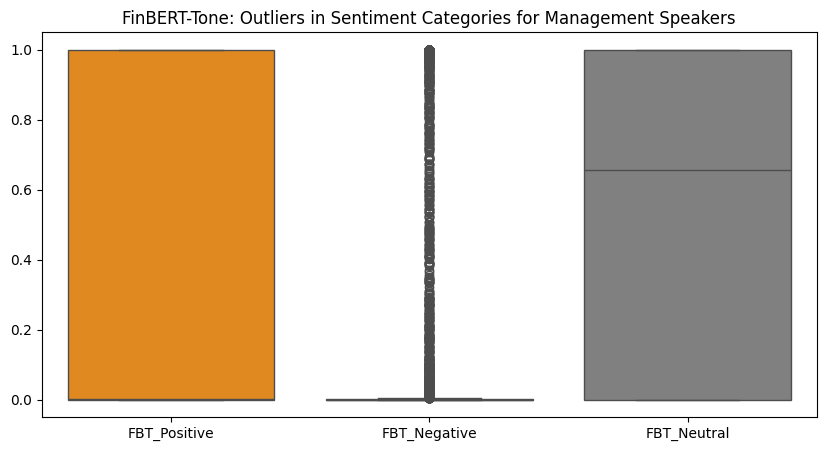

In [397]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
# Use FBT_ columns for the boxplot
sns.boxplot(data=management_data[['FBT_Positive', 'FBT_Negative', 'FBT_Neutral']], palette=sentiment_palette)
plt.title("FinBERT-Tone: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [398]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
FBT_sentiment_stats = data.groupby(["quarter", "FBT_Main_Sentiment", "speaker_role","section"]).agg(
    median_score=("FBT_Main_Sentiment_Score", "median"),
    std_score=("FBT_Main_Sentiment_Score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
FBT_sentiment_stats = FBT_sentiment_stats[FBT_sentiment_stats['speaker_role'] != 'analyst']
FBT_sentiment_stats.head(10)   

,quarter,FBT_Main_Sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,Negative,management,prepared,0.999796,0.098055
2,2022-Q1,Negative,management,qa,0.984596,0.113034
4,2022-Q1,Neutral,management,prepared,0.999445,0.071238
5,2022-Q1,Neutral,management,qa,0.999387,0.101686
6,2022-Q1,Neutral,operator,qa,0.990082,0.002558
8,2022-Q1,Positive,management,prepared,0.999986,0.082320
9,2022-Q1,Positive,management,qa,0.999946,0.149236
11,2022-Q2,Negative,management,prepared,0.999933,0.103753
12,2022-Q2,Negative,management,qa,0.961982,0.175524
14,2022-Q2,Neutral,management,prepared,0.999655,0.114986


In [399]:
# Calculate max and mean values for std_score for sentiments
FBT_sentiment_std_max = FBT_sentiment_stats.groupby('FBT_Main_Sentiment')['std_score'].max()
FBT_sentiment_std_mean = FBT_sentiment_stats.groupby('FBT_Main_Sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(FBT_sentiment_std_max)
print("\nMean std_score per sentiment:")
print(FBT_sentiment_std_mean)

Max std_score per sentiment:
FBT_Main_Sentiment
Negative    0.237423
Neutral     0.140788
Positive    0.163265
Name: std_score, dtype: float64

Mean std_score per sentiment:
FBT_Main_Sentiment
Negative    0.134281
Neutral     0.088495
Positive    0.088725
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [400]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_FBT_sentiment_stats = FBT_sentiment_stats.pivot_table(index=['quarter', 'FBT_Main_Sentiment'], columns='section', values='median_score').reset_index()
diff_FBT_sentiment_stats = diff_FBT_sentiment_stats.fillna(0)
diff_FBT_sentiment_stats['diff'] = diff_FBT_sentiment_stats['qa'] - diff_FBT_sentiment_stats['prepared']

In [401]:
diff_FBT_sentiment_stats.head(10)

section,quarter,FBT_Main_Sentiment,prepared,qa,diff
0,2022-Q1,Negative,0.999796,0.984596,-0.015200
1,2022-Q1,Neutral,0.999445,0.994734,-0.004711
2,2022-Q1,Positive,0.999986,0.999946,-0.000039
3,2022-Q2,Negative,0.999933,0.961982,-0.037951
4,2022-Q2,Neutral,0.999655,0.999578,-0.000078
5,2022-Q2,Positive,0.999995,0.999989,-0.000006
6,2022-Q3,Negative,0.999875,0.980083,-0.019793
7,2022-Q3,Neutral,0.999356,0.999516,0.000160
8,2022-Q3,Positive,0.999999,0.999974,-0.000024
9,2022-Q4,Negative,0.999988,0.972650,-0.027338


In [402]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_FBT_sentiment_std_max = FBT_sentiment_std_max.max()
print("Value for error bars: ", all_FBT_sentiment_std_max)

Value for error bars:  0.23742331790564022


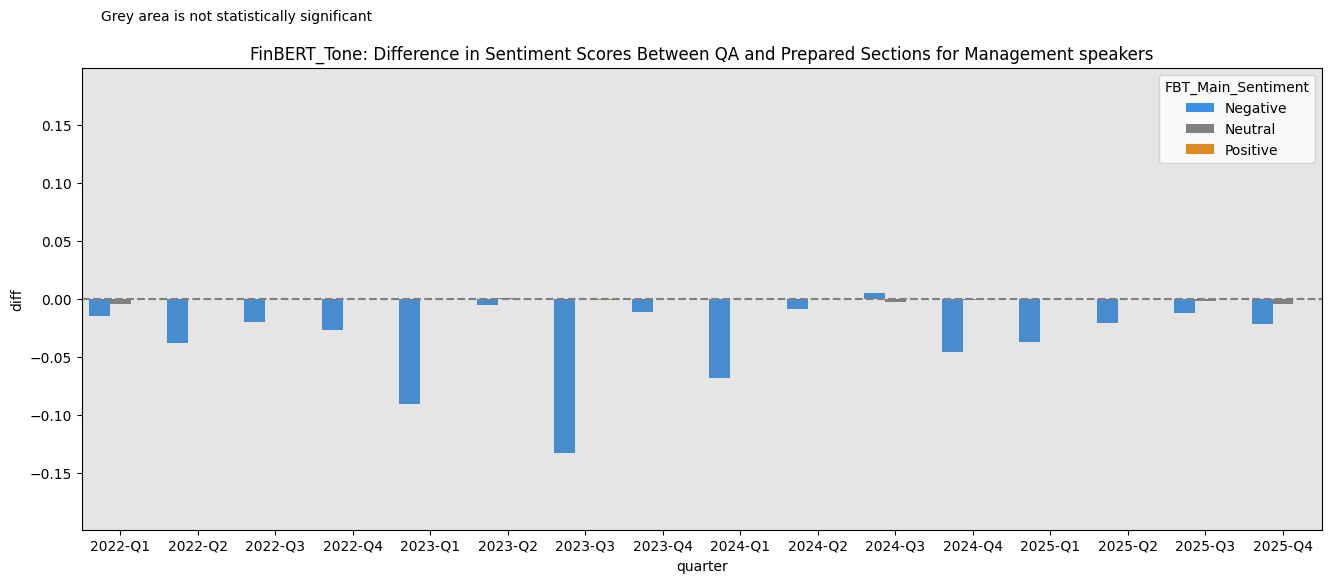

In [403]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_FBT_sentiment_stats, x="quarter", y="diff", hue="FBT_Main_Sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
FBT_diff_range = diff_FBT_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-FBT_diff_range, FBT_diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_FBT_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_FBT_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_FBT_sentiment_std_max,
    all_FBT_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT_Tone: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_FBT_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/FinBERT-Tone_sentiment_differences_{bank_name}.png")

# Compare FinBERT-Tone and BERT-Emotion

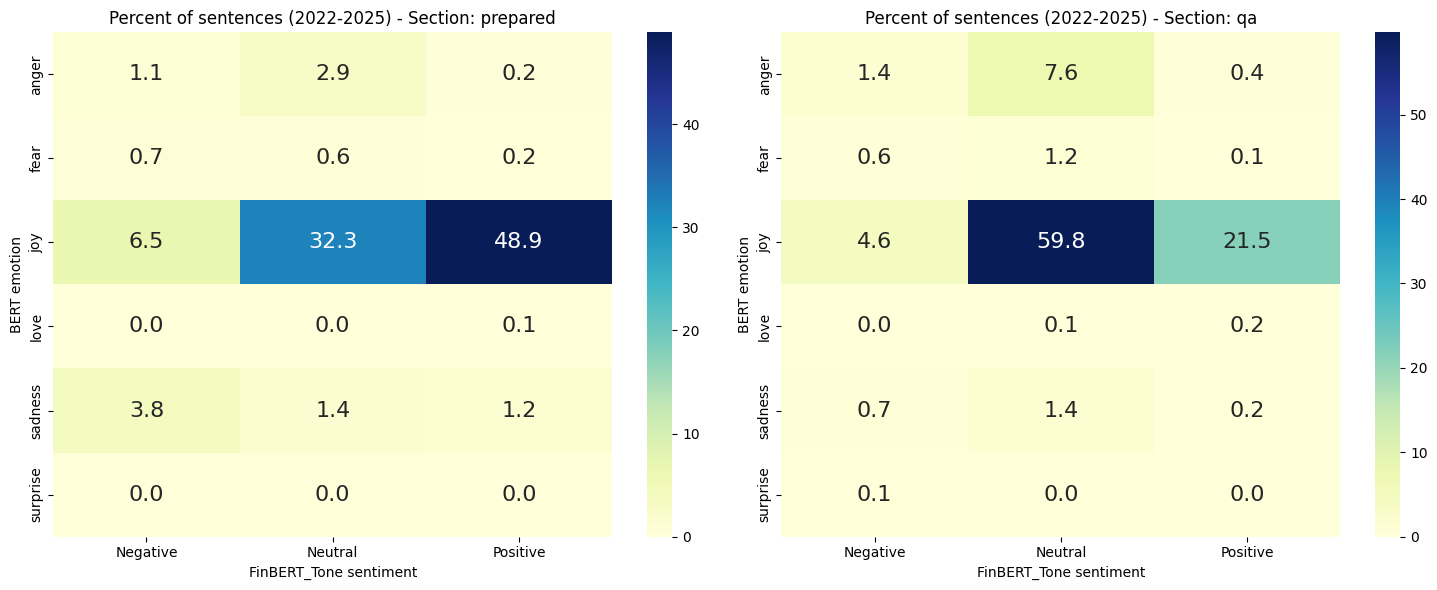

In [404]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'FBT_Main_Sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT_Tone sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save data in dataframe for final comparison with other heatmaps
comparison_data2 = []
for section in sections[:2]:
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'FBT_Main_Sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    comparison_data2.append((section, heatmap_data))
comparison_df2 = pd.concat([df for section, df in comparison_data2], keys=[section for section, df in comparison_data2])

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# Save figure in bank folder
fig.savefig(f'{results_folder}/BERT_emotion_vs_FinBERT_Tone_{bank_name}.png')
plt.show()

# Compare FinBERT-Tone and FinBERT

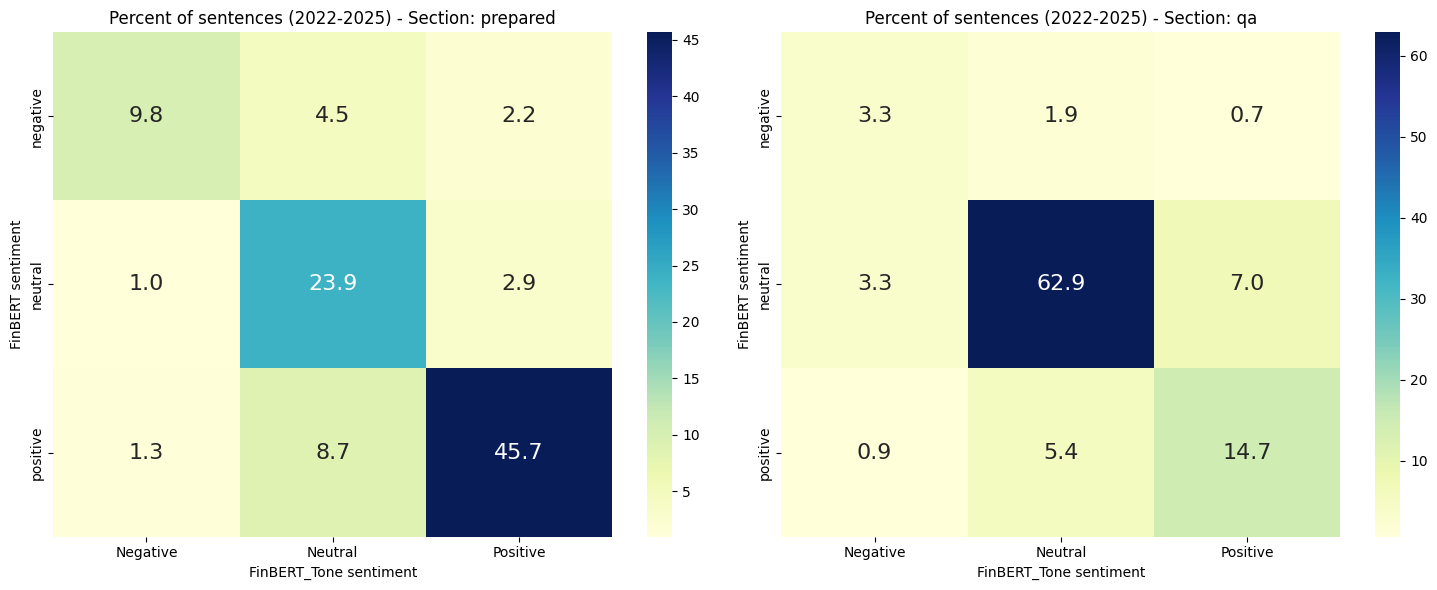

In [405]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'FBT_Main_Sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT_Tone sentiment')
    axes[i].set_ylabel('FinBERT sentiment')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# Save figure in bank folder
fig.savefig(f'{results_folder}/FinBERT_vs_FinBERT_Tone_{bank_name}.png')
plt.show()

# RoBERTa Model

## Build pipeline

In [406]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Load RoBERTa model and tokenizer
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["sentence"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 66597.29it/s]


## Run the model

In [407]:
# Run the model and keep all sentiment scores
basic_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["RBT_main_sentiment"] = [
    max(row, key=row.get, default="LABEL_1") if row else "LABEL_1"
    for row in sentiment_rows
]
data["RBT_main_sentiment_score"] = [
    row.get(max(row, key=row.get, default="LABEL_1"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
for sentiment in ["LABEL_0", "LABEL_1", "LABEL_2"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]
data.rename(columns={"LABEL_0": "RBT_negative", "LABEL_1": "RBT_neutral", "LABEL_2": "RBT_positive"}, inplace=True)

# Map main_sentiment to "LABEL_0": "negative","LABEL_1": "neutral" and "LABEL_2": "positive"
label_mapping = {
    "LABEL_0": "RBT_negative",
    "LABEL_1": "RBT_neutral",
    "LABEL_2": "RBT_positive",
}
data["RBT_main_sentiment"] = data["RBT_main_sentiment"].map(label_mapping)

In [408]:
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,FBT_Positive,FBT_Negative,FBT_Neutral,RBT_main_sentiment,RBT_main_sentiment_score,RBT_negative,RBT_neutral,RBT_positive
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,Neutral,0.730677,2.659177e-01,3.404834e-03,7.306774e-01,RBT_positive,0.886279,0.005244,0.108477,0.886279
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,Negative,0.999783,5.178038e-07,9.997831e-01,2.163999e-04,RBT_neutral,0.719678,0.174356,0.719678,0.105966
9908,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33598,...,Neutral,0.990717,9.016610e-03,2.660466e-04,9.907174e-01,RBT_positive,0.583625,0.014727,0.401647,0.583625
9909,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33599,...,Positive,1.000000,1.000000e+00,8.091497e-09,9.997575e-09,RBT_positive,0.969437,0.001227,0.029336,0.969437
9910,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33600,...,Positive,0.998810,9.988101e-01,1.425757e-05,1.175712e-03,RBT_positive,0.850888,0.003286,0.145826,0.850888
9911,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33601,...,Negative,0.919886,4.003507e-04,9.198859e-01,7.971376e-02,RBT_neutral,0.711036,0.024864,0.711036,0.264100
9912,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33602,...,Positive,0.735830,7.358295e-01,4.288970e-04,2.637415e-01,RBT_neutral,0.833075,0.063361,0.833075,0.103564
9913,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33603,...,Neutral,0.787062,1.874658e-01,2.547235e-02,7.870619e-01,RBT_neutral,0.505175,0.024892,0.505175,0.469933
9914,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33604,...,Positive,1.000000,1.000000e+00,6.737541e-09,7.060855e-09,RBT_positive,0.946214,0.001604,0.052183,0.946214
9915,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33605,...,Positive,1.000000,9.999995e-01,2.540272e-08,4.483727e-07,RBT_positive,0.898679,0.002365,0.098956,0.898679


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

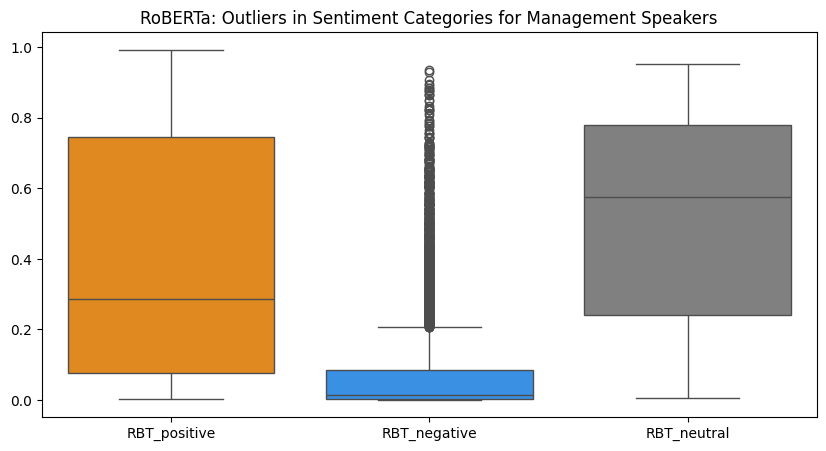

In [409]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
# Use RBT_ columns for the boxplot
sns.boxplot(data=management_data[['RBT_positive', 'RBT_negative', 'RBT_neutral']], palette=sentiment_palette)
plt.title("RoBERTa: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [410]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
RBT_sentiment_stats = data.groupby(["quarter", "RBT_main_sentiment", "speaker_role","section"]).agg(
    median_score=("RBT_main_sentiment_score", "median"),
    std_score=("RBT_main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
RBT_sentiment_stats = RBT_sentiment_stats[RBT_sentiment_stats['speaker_role'] != 'analyst']
RBT_sentiment_stats.head(10)   

,quarter,RBT_main_sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,RBT_negative,management,prepared,0.612737,0.058756
2,2022-Q1,RBT_negative,management,qa,0.578163,0.084640
4,2022-Q1,RBT_neutral,management,prepared,0.671812,0.124639
5,2022-Q1,RBT_neutral,management,qa,0.762091,0.118877
6,2022-Q1,RBT_neutral,operator,qa,0.923443,0.021516
8,2022-Q1,RBT_positive,management,prepared,0.748724,0.133132
9,2022-Q1,RBT_positive,management,qa,0.818837,0.160065
11,2022-Q2,RBT_negative,management,prepared,0.605713,0.140271
12,2022-Q2,RBT_negative,management,qa,0.630971,0.072668
14,2022-Q2,RBT_neutral,management,prepared,0.736929,0.124093


In [411]:
# Calculate max and mean values for std_score for sentiments
RBT_sentiment_std_max = RBT_sentiment_stats.groupby('RBT_main_sentiment')['std_score'].max()
RBT_sentiment_std_mean = RBT_sentiment_stats.groupby('RBT_main_sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(RBT_sentiment_std_max)
print("\nMean std_score per sentiment:")
print(RBT_sentiment_std_mean)

Max std_score per sentiment:
RBT_main_sentiment
RBT_negative    0.170338
RBT_neutral     0.133704
RBT_positive    0.168583
Name: std_score, dtype: float64

Mean std_score per sentiment:
RBT_main_sentiment
RBT_negative    0.088504
RBT_neutral     0.106519
RBT_positive    0.128505
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [412]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_RBT_sentiment_stats = RBT_sentiment_stats.pivot_table(index=['quarter', 'RBT_main_sentiment'], columns='section', values='median_score').reset_index()
diff_RBT_sentiment_stats = diff_RBT_sentiment_stats.fillna(0)
diff_RBT_sentiment_stats['diff'] = diff_RBT_sentiment_stats['qa'] - diff_RBT_sentiment_stats['prepared']

In [413]:
diff_RBT_sentiment_stats.head(10)

section,quarter,RBT_main_sentiment,prepared,qa,diff
0,2022-Q1,RBT_negative,0.612737,0.578163,-0.034574
1,2022-Q1,RBT_neutral,0.671812,0.842767,0.170955
2,2022-Q1,RBT_positive,0.748724,0.818837,0.070113
3,2022-Q2,RBT_negative,0.605713,0.630971,0.025258
4,2022-Q2,RBT_neutral,0.736929,0.770168,0.033239
5,2022-Q2,RBT_positive,0.812300,0.769748,-0.042552
6,2022-Q3,RBT_negative,0.633696,0.558550,-0.075146
7,2022-Q3,RBT_neutral,0.772358,0.750917,-0.021441
8,2022-Q3,RBT_positive,0.794542,0.756573,-0.037968
9,2022-Q4,RBT_negative,0.587034,0.573187,-0.013847


In [414]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_RBT_sentiment_std_max = RBT_sentiment_std_max.max()
print("Value for error bars: ", all_RBT_sentiment_std_max)

Value for error bars:  0.17033774247604963


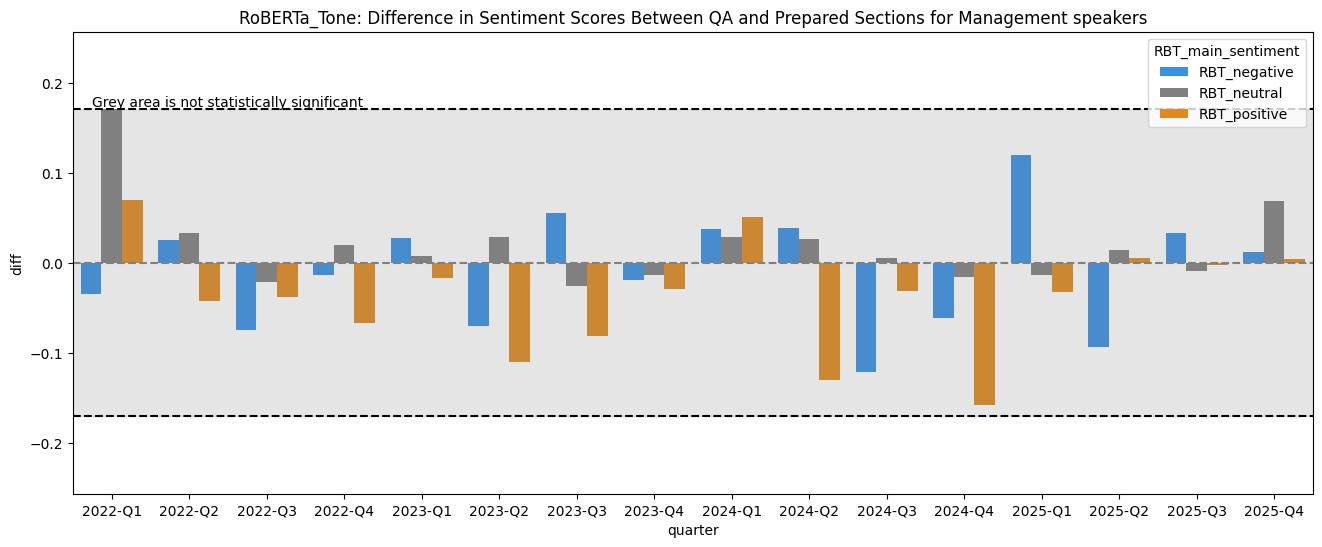

In [415]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_RBT_sentiment_stats, x="quarter", y="diff", hue="RBT_main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_RBT_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_RBT_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_RBT_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_RBT_sentiment_std_max,
    all_RBT_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("RoBERTa_Tone: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_RBT_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/RoBERTa-Tone_sentiment_differences_{bank_name}.png")

# Compare RoBERTa and BERT-Emotion

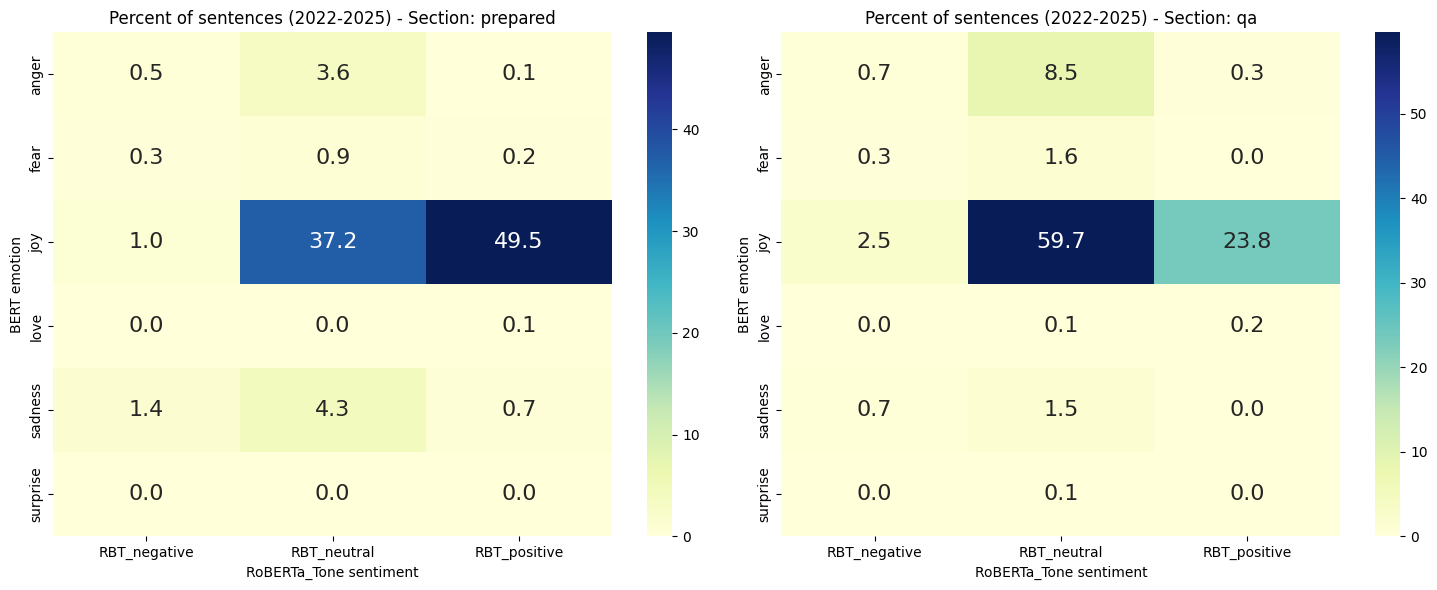

In [416]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'RBT_main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('RoBERTa_Tone sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save data in dataframe for final comparison with other heatmaps
comparison_data3 = []
for section in sections[:2]:
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'RBT_main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    comparison_data3.append((section, heatmap_data))
comparison_df3 = pd.concat([df for section, df in comparison_data3], keys=[section for section, df in comparison_data3])

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# save figure in bank folder
fig.savefig(f'{results_folder}/BERT_emotion_vs_RoBERTa_Tone_{bank_name}.png')

plt.show()

# Save Output

In [417]:
# Save output as csv file with bank name in title in bank folder
output_file = f"{results_folder}/sentiment_classification_output_{bank_name}.csv"
data.to_csv(output_file, index=False)
print(f"Output saved to {output_file}")

Output saved to results_UBS/sentiment_classification_output_UBS.csv


# Tone Gap Analysis

In [418]:
# Collect results from heatmap comparisons into one dataframe
comparison_df_all = pd.concat([comparison_df1, comparison_df2, comparison_df3], axis=1, keys=['FinBERT', 'FinBERT_Tone', 'RoBERTa_Tone'])
comparison_df_all.head(12)


FinBERT                       FinBERT_Tone             \
                       negative    neutral   positive     Negative    Neutral   
         main_emotion                                                           
prepared anger         1.745152   2.105263   0.387812     1.052632   2.936288   
         fear          0.803324   0.360111   0.277008     0.720222   0.554017   
         joy           9.224377  24.598338  53.905817     6.537396  32.271468   
         love          0.000000   0.027701   0.110803     0.000000   0.027701   
         sadness       4.736842   0.747922   0.941828     3.767313   1.412742   
         surprise      0.000000   0.000000   0.027701     0.000000   0.000000   
qa       anger         0.791738   8.158348   0.516351     1.411360   7.641997   
         fear          0.275387   1.445783   0.206540     0.585198   1.239243   
         joy           3.820998  62.237522  19.862306     4.647160  59.759036   
         love          0.000000   0.068847   0.206540     0.000000   0.068847   
         sadness       0.791738   1.239243   0.206540     0.654045   1.411360   
         surprise      0.103270   0.034423   0.034423     0.137694   0.034423   

                                 RoBERTa_Tone                           
                        Positive RBT_negative RBT_neutral RBT_positive  
         main_emotion                                                   
prepared anger          0.249307     0.498615    3.628809     0.110803  
         fear           0.166205     0.332410    0.886427     0.221607  
         joy           48.919668     0.997230   37.202216    49.529086  
         love           0.110803     0.000000    0.000000     0.138504  
         sadness        1.246537     1.385042    4.321330     0.720222  
         surprise       0.027701     0.000000    0.000000     0.027701  
qa       anger          0.413081     0.688468    8.468158     0.309811  
         fear           0.103270     0.309811    1.583477     0.034423  
         joy           21.514630     2.512909   59.655766    23.752151  
         love           0.206540     0.000000    0.068847     0.206540  
         sadness        0.172117     0.688468    1.514630     0.034423  
         surprise       0.000000     0.000000    0.137694     0.034423

In [419]:
# Create a dataframe just for main_emotion = 'joy'
comparison_df_joy = comparison_df_all.xs('joy', level=1, axis=0)
comparison_df_joy.head(12)

FinBERT                       FinBERT_Tone                        \
          negative    neutral   positive     Negative    Neutral   Positive   
prepared  9.224377  24.598338  53.905817     6.537396  32.271468  48.919668   
qa        3.820998  62.237522  19.862306     4.647160  59.759036  21.514630   

         RoBERTa_Tone                           
         RBT_negative RBT_neutral RBT_positive  
prepared     0.997230   37.202216    49.529086  
qa           2.512909   59.655766    23.752151

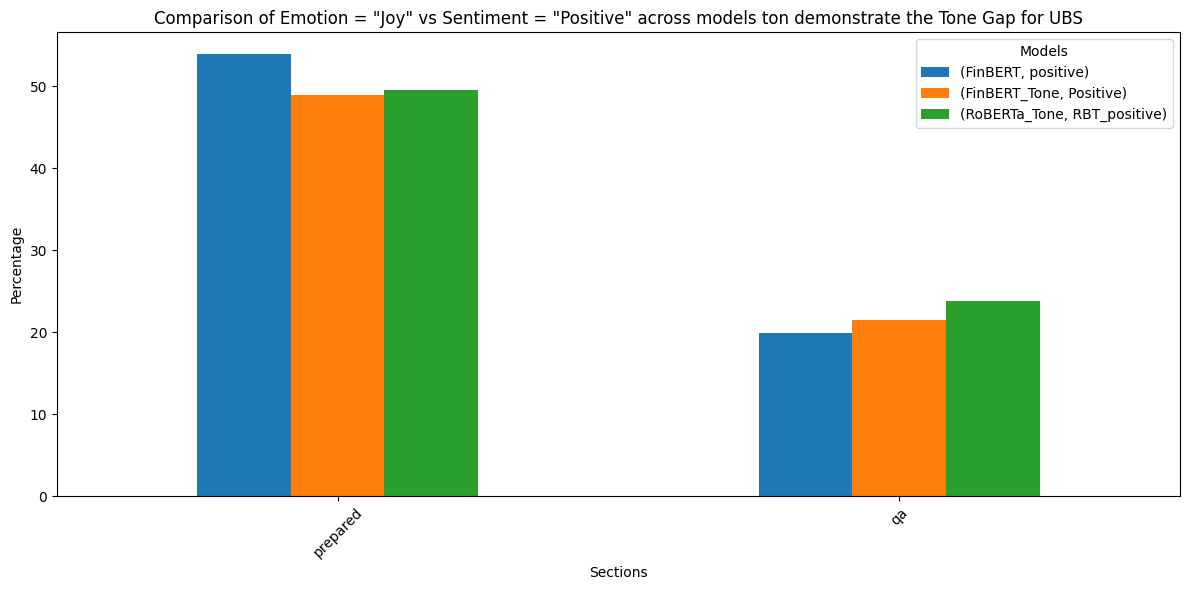

In [420]:
# Plot "joy" vs positive, Positive and RBT_positive for prepared and qa categories
comparison_df_joy_subset = comparison_df_joy.loc[:, [('FinBERT', 'positive'), ('FinBERT_Tone', 'Positive'), ('RoBERTa_Tone', 'RBT_positive')]]
comparison_df_joy_subset = comparison_df_joy_subset.loc[['prepared', 'qa']]
comparison_df_joy_subset.plot(kind='bar', figsize=(12, 6))
plt.title(f'Comparison of Emotion = "Joy" vs Sentiment = "Positive" across models ton demonstrate the Tone Gap for {bank_name}')
plt.ylabel('Percentage')
plt.xlabel('Sections')
plt.xticks(rotation=45)
plt.legend(title='Models')
plt.tight_layout()
# save figure for bank name
plt.savefig(f'{results_folder}/joy_vs_positive_{bank_name}.png')
plt.show()


# Apply BERTopic to sentences classified by FinBERT sentiments

In [421]:
data[['cleaned_text','sentence']].head(20)

,cleaned_text,sentence
9905,[thank],Thank you Sarah.
9907,"[first, quarter, dominated, extraordinary, geo...",The first quarter of 2022 was dominated by ext...
9908,"[turbulent, time, remained, focused, three, ke...","And during these turbulent times, we’ve remain..."
9909,"[proved, benefit, global, scale, power, ecosys...",We once again proved the benefits of our globa...
9910,"[working, hard, enhance, every, day]",And we’re working hard to enhance them every day.
9911,"[client, navigate, challenging, complex, envir...",Our clients had to navigate a challenging and ...
9912,"[time, prudently, managed, risk]","At the same time, we prudently managed our own..."
9913,"[working, together, across, business, control,...",By working together across the businesses and ...
9914,"[focus, client, risk, management, resulted, an...",Our focus on clients and risk management resul...
9915,"[highlighted, resilience, diversified, business]",And it highlighted the resilience of our diver...


In [422]:
# Check cleaned_text for words like "thats" and "dont"
targets = {"thats", "dont"}
data[data["cleaned_text"].apply(
    lambda t: isinstance(t, (list, tuple)) and any(w.lower() in targets for w in t)
)]
# Show these sentences containing the target words
data.loc[data["cleaned_text"].apply(
    lambda t: isinstance(t, (list, tuple)) and any(w.lower() in targets for w in t)
), "cleaned_text"]

Series([], Name: cleaned_text, dtype: object)

## Sentences where FinBERT = Negative

In [423]:
# Create dataframe with sentences and speakers and quarters but only where main_sentiment = negative

negative_sentences = data[data['main_sentiment'] == 'negative'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
negative_sentences = negative_sentences.sort_values(by=['quarter', 'speaker_role'])

negative_sentences.head(4)

,quarter,speaker_name,speaker_role,sentence,cleaned_text,main_sentiment,main_sentiment_score
10265,2022-Q1,Jeremy Sigee,analyst,You know you've obviously told us that there's...,"[know, obviously, told, u, op, risk, coming]",negative,0.413204
10317,2022-Q1,Amit Goel,analyst,So what you're seeing there and whether the ma...,"[seeing, whether, margin, stable, steady, whet...",negative,0.558548
10354,2022-Q1,Adam Terelak,analyst,"On the guidance of 1 billion, I just want to m...","[guidance, billion, want, make, sure, got, app...",negative,0.925063
10361,2022-Q1,Adam Terelak,analyst,I think that's the level when in previous cycl...,"[think, level, previous, cycle, saw, bit, term...",negative,0.495505


### BERTopic Analysis using function to apply to any year

In [424]:
import ast
from bertopic import BERTopic
from umap import UMAP

# Not sure what ast and UMAP actually do !
# ast is used to safely evaluate strings containing Python literals (like lists) into actual Python objects.
# UMAP is a dimensionality reduction technique often used to preprocess data for clustering or topic modeling.

def plot_negative_topics_for_year(data, year, bank=bank_name, min_topic_size=10, top_n_words=3):
    """Run BERTopic on a year's negative sentences and plot topic counts as a bar chart.

    Returns (topic_model, topic_info), or (None, None) if no topics were found.
    """
    year = str(year)
    quarters = [f"{year}-Q{q}" for q in range(1, 5)]

    # Negative sentences for the year
    yr_data = data[(data["main_sentiment"] == "negative") & (data["quarter"].isin(quarters))]

    # Adapt text from "strings of lists" format in csv file, dropping empty sentences
    #texts = [" ".join(ast.literal_eval(t)) for t in yr_data["cleaned_text"]]
    texts = [" ".join(tokens) for tokens in yr_data["cleaned_text"]]
    texts = [t for t in texts if t.strip() != ""]
    print(f"Number of negative sentences for BERTopic modelling in {year}: {len(texts)}")

    topic_model = BERTopic(
        umap_model=UMAP(random_state=42, n_jobs=1),
        min_topic_size=min_topic_size,
        calculate_probabilities=False,
    )
    topic_model.fit_transform(texts)
    topic_info = topic_model.get_topic_info()

    plot_info = topic_info[topic_info["Topic"] != -1].sort_values("Count")  # drop the outlier "topic"
    if plot_info.empty:
        print(f"No topics found for {year} (only outliers); try a smaller min_topic_size.")
        return None, topic_info

    # Shorten names like "0_rates_margin_nii_cost" to "rates, margin, nii"
    labels = [", ".join(name.split("_")[1:1 + top_n_words]) for name in plot_info["Name"]]

    fig, ax = plt.subplots(figsize=(10, 0.45 * len(plot_info) + 1.5))
    bars = ax.barh(labels, plot_info["Count"], color="steelblue")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of negative sentences")
    ax.set_title(f"{bank} negative sentences by BERTopic topic for year = {year}")
    plt.tight_layout()
    plt.show()
    return topic_model, topic_info

Number of negative sentences for BERTopic modelling in 2022: 193


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8520.80it/s]


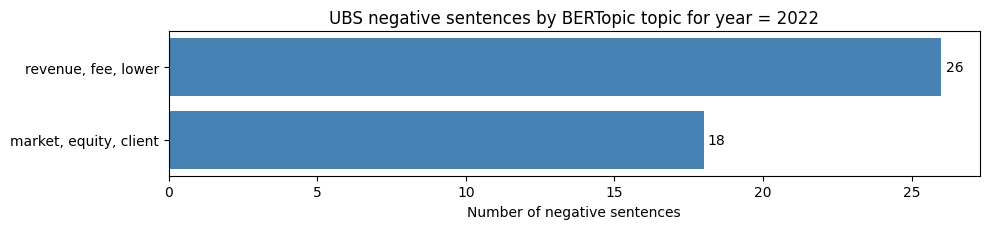

Number of negative sentences for BERTopic modelling in 2023: 257


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13631.62it/s]


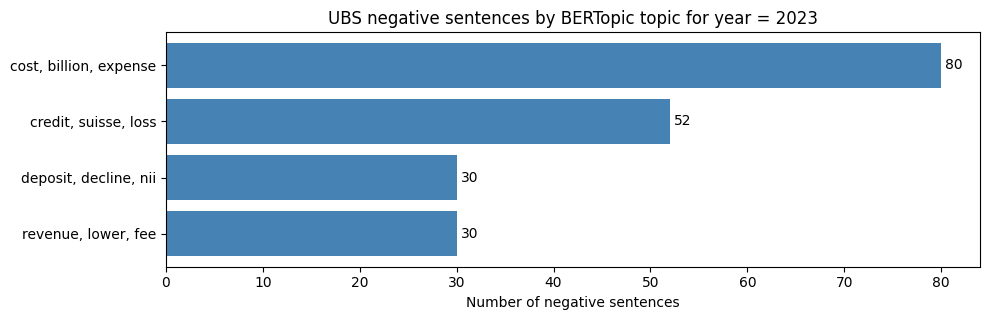

Number of negative sentences for BERTopic modelling in 2024: 241


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12423.10it/s]


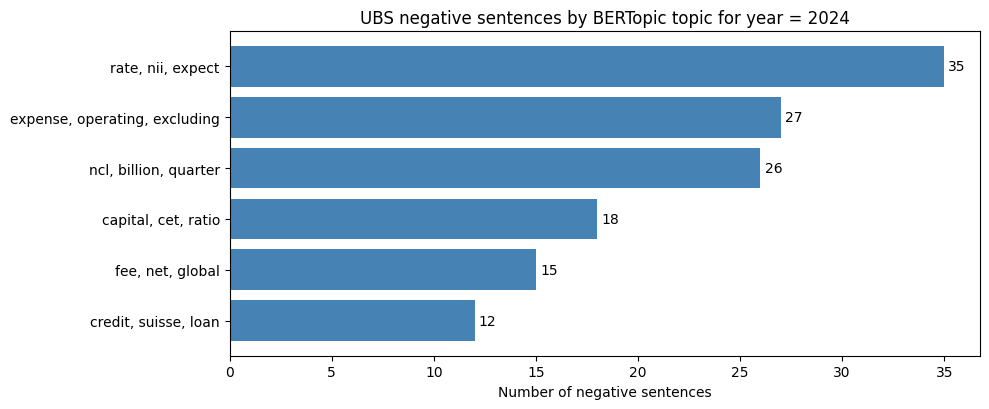

Number of negative sentences for BERTopic modelling in 2025: 214


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13998.68it/s]


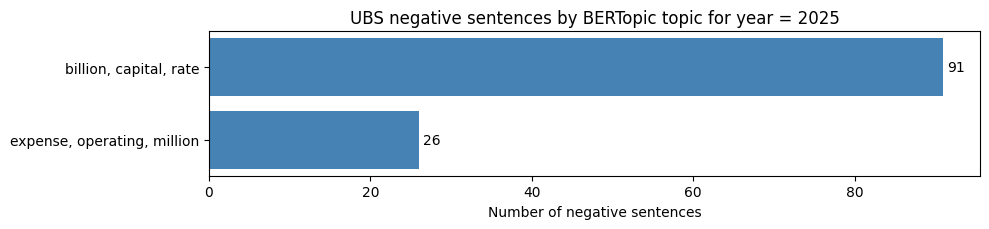

In [425]:
YR_topic_model_22, YR_topic_info_22 = plot_negative_topics_for_year(data, "2022")
YR_topic_model_23, YR_topic_info_23 = plot_negative_topics_for_year(data, "2023")
YR_topic_model_24, YR_topic_info_24 = plot_negative_topics_for_year(data, "2024")
YR_topic_model_25, YR_topic_info_25 = plot_negative_topics_for_year(data, "2025")


In [426]:
# Collect yr_topic_info for all years into one dataframe for plotting, include year as a column
all_YR_topic_info = pd.concat([
    YR_topic_info_22.assign(year="2022"),
    YR_topic_info_23.assign(year="2023"),
    YR_topic_info_24.assign(year="2024"),
    YR_topic_info_25.assign(year="2025")
])
all_YR_topic_info.reset_index(drop=True, inplace=True)

In [427]:
# Add new column for plotting as legend to all_YR_topic_info
# remove numbers and replace underscores with commas
all_YR_topic_info["Legend"] = all_YR_topic_info["Name"].apply(
    lambda x: ", ".join(x.split("_")[1:])
)
all_YR_topic_info.head()


,Topic,Count,Name,Representation,Representative_Docs,year,Legend
0,-1,149,-1_quarter_million_year_expense,"[quarter, million, year, expense, also, fx, re...",[last year market high basically held back rec...,2022,"quarter, million, year, expense"
1,0,26,0_revenue_fee_lower_global,"[revenue, fee, lower, global, gwm, management,...",[underlying revenue exfx increase nii gwm pc o...,2022,"revenue, fee, lower, global"
2,1,18,1_market_equity_client_affected,"[market, equity, client, affected, level, busi...",[excluding money market saw billion inflow sus...,2022,"market, equity, client, affected"
3,-1,65,-1_net_slide_deposit_asset,"[net, slide, deposit, asset, income, moving, o...",[net interest income reflecting tapering depos...,2023,"net, slide, deposit, asset"
4,0,80,0_cost_billion_expense_ncl,"[cost, billion, expense, ncl, operating, expec...",[operating expense declined billion billion ma...,2023,"cost, billion, expense, ncl"


### BERTopic - final plot

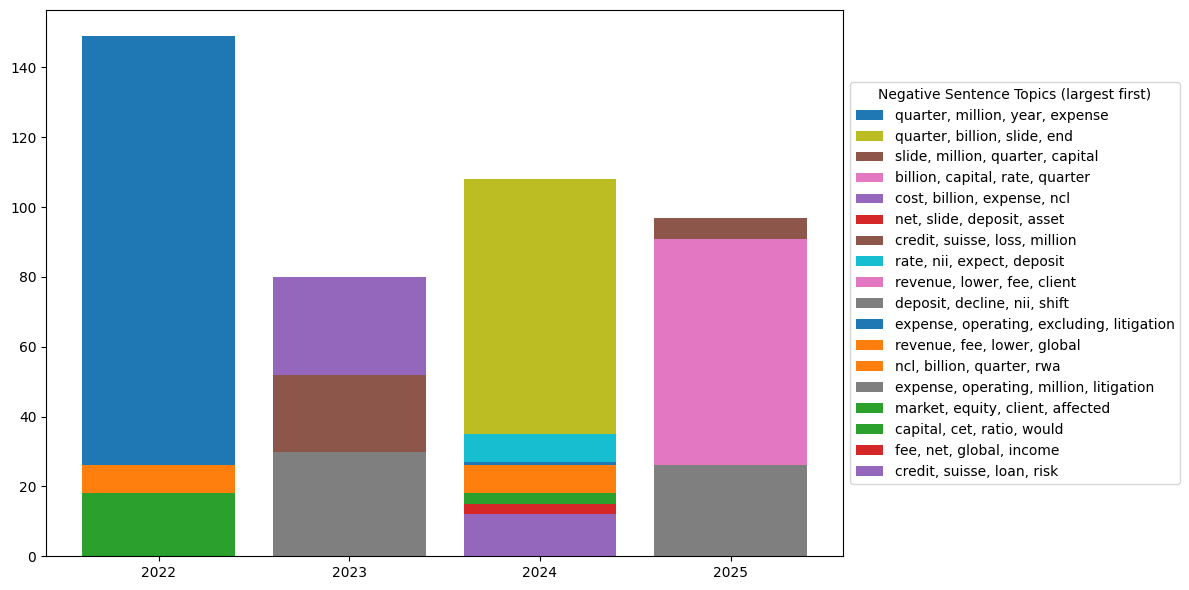

In [428]:

fig, ax = plt.subplots(figsize=(12, 6))

for topic in all_YR_topic_info["Name"].unique():
    topic_data = all_YR_topic_info[all_YR_topic_info["Name"] == topic]
    ax.bar(topic_data["year"], topic_data["Count"], label=topic_data["Legend"].iloc[0])

# Total count per legend label, used for ordering
totals = all_YR_topic_info.groupby("Legend")["Count"].sum()

handles, labels = ax.get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: totals[labels[i]], reverse=True)

ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc="center left",
    bbox_to_anchor=(1, 0.5),   # legend at the side
    title="Negative Sentence Topics (largest first)",
)
plt.tight_layout()
# save figure in bank folder
plt.savefig(f"{results_folder}/negative_sentence_topics_by_year_for_{bank_name}.png")
plt.show()

### BertTopic by Quarter

In [429]:
import ast
from bertopic import BERTopic
from umap import UMAP
import pandas as pd

def _cleaned_to_text(value):
    """Turn a token list, a stringified token list, or a plain string into one string."""
    if isinstance(value, (list, tuple)):
        return " ".join(map(str, value)).strip()
    if isinstance(value, str):
        v = value.strip()
        if v.startswith("[") and v.endswith("]"):
            try:
                return " ".join(map(str, ast.literal_eval(v))).strip()
            except (ValueError, SyntaxError):
                pass
        return v
    return ""

def find_top_negative_topics_per_quarter(
    data,
    bank=None,
    min_topic_size=5,
    top_n_topics=3,
    top_n_words=5,
    n_examples=2,
    text_col="cleaned_text",
):
    required = {"quarter", "main_sentiment", text_col}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    if bank is not None and "bank" not in data.columns:
        raise ValueError("A 'bank' column is required when filtering by bank.")
    if min_topic_size < 2 or top_n_topics < 1:
        raise ValueError("min_topic_size must be at least 2 and top_n_topics at least 1.")

    subset = data[data["main_sentiment"].eq("negative")].copy()
    if bank is not None:
        subset = subset[subset["bank"].eq(bank)]

    # Original sentences are used for examples when available
    example_col = "sentence" if "sentence" in subset.columns else text_col

    results = []

    for quarter, quarter_data in subset.groupby("quarter", sort=True):
        quarter_data = quarter_data.copy()
        quarter_data["_text"] = quarter_data[text_col].apply(_cleaned_to_text)
        quarter_data = quarter_data[quarter_data["_text"].ne("")]

        if len(quarter_data) < 2:
            print(f"Skipping {quarter}: fewer than 2 non-empty texts.")
            continue

        topic_model = BERTopic(
            umap_model=UMAP(random_state=42, n_jobs=1),
            min_topic_size=min_topic_size,
            calculate_probabilities=False,
        )

        topics, _ = topic_model.fit_transform(quarter_data["_text"].tolist())
        quarter_data["topic"] = topics

        top_topics = (
            topic_model.get_topic_info()
            .query("Topic != -1")
            .sort_values("Count", ascending=False)
            .head(top_n_topics)
        )

        if top_topics.empty:
            print(f"No non-outlier topics found for {quarter}.")
            continue

        for topic in top_topics.itertuples(index=False):
            topic_words = topic_model.get_topic(topic.Topic) or []
            keywords = ", ".join(word for word, _ in topic_words[:top_n_words])
            examples = quarter_data.loc[
                quarter_data["topic"].eq(topic.Topic), example_col
            ].head(n_examples).astype(str).tolist()

            results.append({
                "quarter": quarter,
                "topic": topic.Topic,
                "count": topic.Count,
                "keywords": keywords,
                "example_sentences": examples,
            })

    return pd.DataFrame(results)

In [430]:
top_topics = find_top_negative_topics_per_quarter(data, bank=bank_name)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14162.05it/s]


No non-outlier topics found for 2023-Q1.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13998.68it/s]


In [431]:
display(top_topics)

,quarter,topic,count,keywords,example_sentences
0,2022-Q1,0,20,"revenue, overall, market, also, lower",[The first quarter of 2022 was dominated by ex...
1,2022-Q1,1,5,"loss, million, cost, compared, partly",[This was partly offset by a 16 million valuat...
2,2022-Q2,0,20,"million, loss, net, expense, dollar",[Transaction-based revenues with these clients...
3,2022-Q2,1,8,"market, july, development, mark, meaningfully","[Going to the next slide, basically you see th..."
4,2022-Q3,0,24,"revenue, quarter, lower, market, million","[They're concerned about inflation, about the ..."
5,2022-Q3,1,5,"client, also, willingness, year, restriction","[That said, many of our Swiss retail and small..."
6,2022-Q4,0,15,"fx, expense, year, lower, revenue",[Our economists are projecting that 2023 will ...
7,2022-Q4,1,12,"quarter, equity, fourth, billion, last","[And, lastly, Asia Pacific, the residual impac..."
8,2023-Q2,0,42,"revenue, billion, cost, asset, negative",[The IB consuming no more than 25% of the Grou...
9,2023-Q2,1,19,"credit, suisse, loss, billion, swiss",[Credit Suisse’s business model and business m...


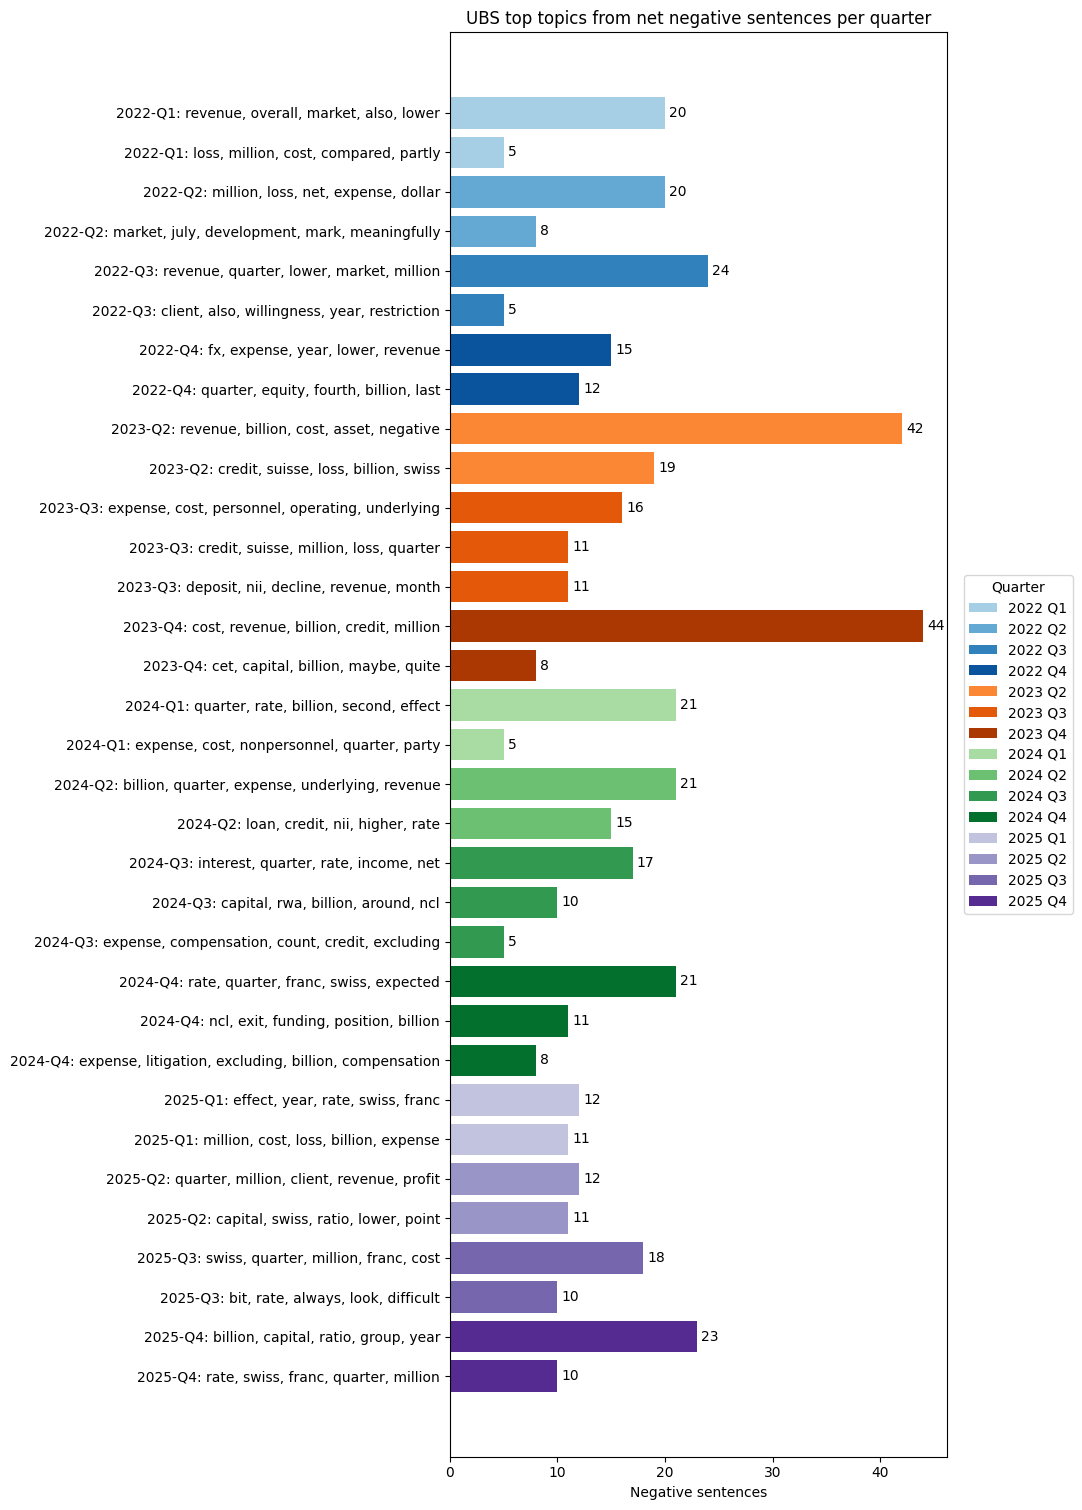

In [432]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_top_topics_single_figure(top_topics, bank=""):
    df = top_topics.copy()
    df["year"] = df["quarter"].str[:4]
    df["q"] = df["quarter"].str[-1].astype(int)

    # Chronological order, largest topic first within each quarter
    df = df.sort_values(["year", "q", "count"], ascending=[True, True, False]).reset_index(drop=True)

    base_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Reds", "Greys"]
    years = sorted(df["year"].unique())
    year_cmap = {y: plt.get_cmap(base_cmaps[i % len(base_cmaps)]) for i, y in enumerate(years)}
    # Q1 lightest -> Q4 darkest
    shade = {1: 0.35, 2: 0.52, 3: 0.69, 4: 0.86}

    colours = [year_cmap[r.year](shade[r.q]) for r in df.itertuples()]


    labels = [f"{r.quarter}: {r.keywords}" for r in df.itertuples()]

    fig, ax = plt.subplots(figsize=(11, 0.4 * len(df) + 2))
    bars = ax.barh(range(len(df)), df["count"], color=colours)
    ax.bar_label(bars, padding=3)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Negative sentences")

    handles = [
        Patch(facecolor=year_cmap[y](shade[q]), label=f"{y} Q{q}")
        for y in years
        for q in sorted(df.loc[df["year"] == y, "q"].unique())
    ]
    ax.legend(handles=handles, title="Quarter", loc="center left",
              bbox_to_anchor=(1.02, 0.5))
    ax.set_title(f"{bank} top topics from net negative sentences per quarter".strip())
    fig.tight_layout()
    # save figure in bank folder
    plt.savefig(f"{results_folder}/negative_sentence_topics_by_quarter_for_{bank_name}.png")

    plt.show()


plot_top_topics_single_figure(top_topics, bank=bank_name)

In [433]:
# Search sentences for the words "First Republic"
first_republic_sentences = data[data["sentence"].str.contains("First Republic", case=False, na=False)]
print(first_republic_sentences[["quarter", "sentence"]])

Empty DataFrame
Columns: [quarter, sentence]
Index: []


In [434]:
# Search the cleaned text to ensure it has come across as first and republic
first_republic_cleaned_text = data[data["cleaned_text"].str.contains("First Republic", case=False, na=False)]
print(first_republic_sentences[["quarter", "sentence", "cleaned_text", "main_sentiment"]])

Empty DataFrame
Columns: [quarter, sentence, cleaned_text, main_sentiment]
Index: []


In [435]:


# Count number of positive, negative and neutral sentences
first_republic_sentiment_counts = first_republic_sentences["main_sentiment"].value_counts()
print("number of positive sentences:", first_republic_sentiment_counts.get("positive", 0))
print("number of negative sentences:", first_republic_sentiment_counts.get("negative", 0))
print("number of neutral sentences:", first_republic_sentiment_counts.get("neutral", 0))

number of positive sentences: 0
number of negative sentences: 0
number of neutral sentences: 0


## Sentences where FinBERT = Positive

In [436]:
# Create dataframe with sentences and speakers and quarters but only where main_sentiment = positive

positive_sentences = data[data['main_sentiment'] == 'positive'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
positive_sentences = data[data['main_sentiment'] == 'positive'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
positive_sentences = positive_sentences.sort_values(by=['quarter', 'speaker_role'])

positive_sentences.shape

(2793, 7)

### BertTopic by Quarter (positive)

In [437]:
import ast
from bertopic import BERTopic
from umap import UMAP
import pandas as pd

def _cleaned_to_text(value):
    """Turn a token list, a stringified token list, or a plain string into one string."""
    if isinstance(value, (list, tuple)):
        return " ".join(map(str, value)).strip()
    if isinstance(value, str):
        v = value.strip()
        if v.startswith("[") and v.endswith("]"):
            try:
                return " ".join(map(str, ast.literal_eval(v))).strip()
            except (ValueError, SyntaxError):
                pass
        return v
    return ""

def find_top_positive_topics_per_quarter(
    data,
    bank=None,
    min_topic_size=5,
    top_n_topics=3,
    top_n_words=5,
    n_examples=2,
    text_col="cleaned_text",
):
    required = {"quarter", "main_sentiment", text_col}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    if bank is not None and "bank" not in data.columns:
        raise ValueError("A 'bank' column is required when filtering by bank.")
    if min_topic_size < 2 or top_n_topics < 1:
        raise ValueError("min_topic_size must be at least 2 and top_n_topics at least 1.")

    subset = data[data["main_sentiment"].eq("positive")].copy()
    if bank is not None:
        subset = subset[subset["bank"].eq(bank)]

    # Original sentences are used for examples when available
    example_col = "sentence" if "sentence" in subset.columns else text_col

    results = []

    for quarter, quarter_data in subset.groupby("quarter", sort=True):
        quarter_data = quarter_data.copy()
        quarter_data["_text"] = quarter_data[text_col].apply(_cleaned_to_text)
        quarter_data = quarter_data[quarter_data["_text"].ne("")]

        if len(quarter_data) < 2:
            print(f"Skipping {quarter}: fewer than 2 non-empty texts.")
            continue

        topic_model = BERTopic(
            umap_model=UMAP(random_state=42, n_jobs=1),
            min_topic_size=min_topic_size,
            calculate_probabilities=False,
        )

        topics, _ = topic_model.fit_transform(quarter_data["_text"].tolist())
        quarter_data["topic"] = topics

        top_topics = (
            topic_model.get_topic_info()
            .query("Topic != -1")
            .sort_values("Count", ascending=False)
            .head(top_n_topics)
        )

        if top_topics.empty:
            print(f"No non-outlier topics found for {quarter}.")
            continue

        for topic in top_topics.itertuples(index=False):
            topic_words = topic_model.get_topic(topic.Topic) or []
            keywords = ", ".join(word for word, _ in topic_words[:top_n_words])
            examples = quarter_data.loc[
                quarter_data["topic"].eq(topic.Topic), example_col
            ].head(n_examples).astype(str).tolist()

            results.append({
                "quarter": quarter,
                "topic": topic.Topic,
                "count": topic.Count,
                "keywords": keywords,
                "example_sentences": examples,
            })

    return pd.DataFrame(results)

In [438]:
top_topics_positive = find_top_positive_topics_per_quarter(data, bank=bank_name)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 16348.66it/s]


In [439]:
display(top_topics_positive)

,quarter,topic,count,keywords,example_sentences
0,2022-Q1,0,50,"client, also, billion, strong, market",[By working together across the businesses and...
1,2022-Q1,1,11,"thank, good, real, done, support","[We’ve also received valuable feedback there.,..."
2,2022-Q1,2,10,"net, feegenerating, fee, asset, new",[We saw 19 billion inflows into fee-generating...
3,2022-Q2,0,113,"quarter, net, year, billion, business","[I think going through, you will see that the ..."
4,2022-Q2,1,8,"client, volatility, show, right, opportunity","[This gain aside, our underlying performance r..."
5,2022-Q3,0,101,"quarter, net, client, new, business",[I'm pleased to share good results with you fo...
6,2022-Q3,1,12,"fx, expense, cost, higher, record",[It also kind of shows the – that our technolo...
7,2022-Q3,2,6,"expect, continue, flow, least, work",[And we expect this to continue at least throu...
8,2022-Q4,0,36,"year, continue, productivity, ratio, costincome","[In the US, we already have over 20% of the Ba..."
9,2022-Q4,1,19,"capital, client, return, strong, shareholder",[We provided sound advice to our clients and p...


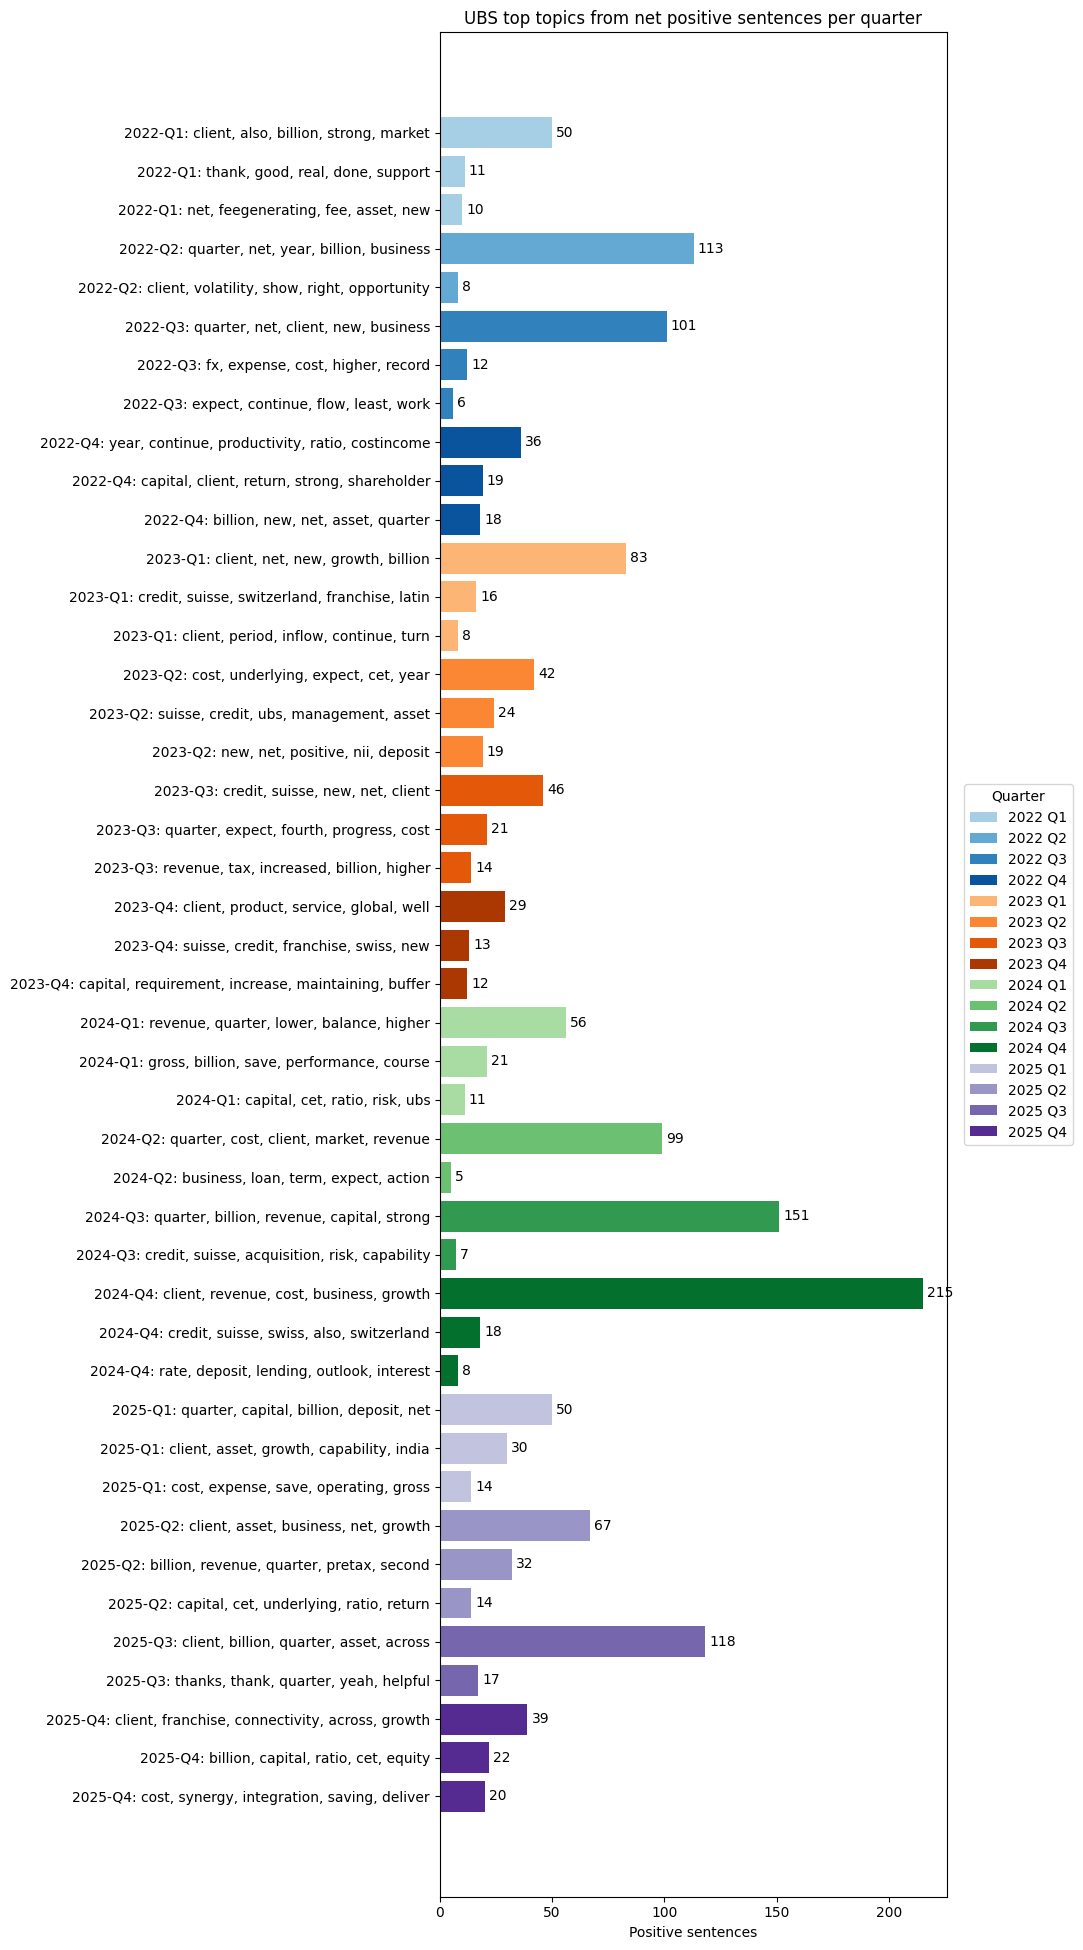

In [440]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_top_topics_single_figure(top_topics, bank=""):
    df = top_topics_positive.copy()
    df["year"] = df["quarter"].str[:4]
    df["q"] = df["quarter"].str[-1].astype(int)

    # Chronological order, largest topic first within each quarter
    df = df.sort_values(["year", "q", "count"], ascending=[True, True, False]).reset_index(drop=True)

    base_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Reds", "Greys"]
    years = sorted(df["year"].unique())
    year_cmap = {y: plt.get_cmap(base_cmaps[i % len(base_cmaps)]) for i, y in enumerate(years)}
    # Q1 lightest -> Q4 darkest
    shade = {1: 0.35, 2: 0.52, 3: 0.69, 4: 0.86}

    colours = [year_cmap[r.year](shade[r.q]) for r in df.itertuples()]


    labels = [f"{r.quarter}: {r.keywords}" for r in df.itertuples()]

    fig, ax = plt.subplots(figsize=(11, 0.4 * len(df) + 2))
    bars = ax.barh(range(len(df)), df["count"], color=colours)
    ax.bar_label(bars, padding=3)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Positive sentences")

    handles = [
        Patch(facecolor=year_cmap[y](shade[q]), label=f"{y} Q{q}")
        for y in years
        for q in sorted(df.loc[df["year"] == y, "q"].unique())
    ]
    ax.legend(handles=handles, title="Quarter", loc="center left",
              bbox_to_anchor=(1.02, 0.5))
    ax.set_title(f"{bank} top topics from net positive sentences per quarter".strip())
    fig.tight_layout()
    # save figure in bank folder
    plt.savefig(f"{results_folder}/positive_sentence_topics_by_quarter_for_{bank_name}.png")

    plt.show()


plot_top_topics_single_figure(top_topics_positive, bank=bank_name)

## Sentences where FinBERT = Neutral

In [441]:
# Repeat Bertopic for neutral sentences
neutral_sentences = data[data['main_sentiment'] == 'neutral'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
neutral_sentences = neutral_sentences.sort_values(by=['quarter', 'speaker_role'])

neutral_sentences.shape

(4519, 7)

### BertTopic by Quarter (neutral)

In [442]:
import ast
from bertopic import BERTopic
from umap import UMAP
import pandas as pd

def _cleaned_to_text(value):
    """Turn a token list, a stringified token list, or a plain string into one string."""
    if isinstance(value, (list, tuple)):
        return " ".join(map(str, value)).strip()
    if isinstance(value, str):
        v = value.strip()
        if v.startswith("[") and v.endswith("]"):
            try:
                return " ".join(map(str, ast.literal_eval(v))).strip()
            except (ValueError, SyntaxError):
                pass
        return v
    return ""

def find_top_neutral_topics_per_quarter(
    data,
    bank=None,
    min_topic_size=5,
    top_n_topics=3,
    top_n_words=5,
    n_examples=2,
    text_col="cleaned_text",
):
    required = {"quarter", "main_sentiment", text_col}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    if bank is not None and "bank" not in data.columns:
        raise ValueError("A 'bank' column is required when filtering by bank.")
    if min_topic_size < 2 or top_n_topics < 1:
        raise ValueError("min_topic_size must be at least 2 and top_n_topics at least 1.")

    subset = data[data["main_sentiment"].eq("neutral")].copy()
    if bank is not None:
        subset = subset[subset["bank"].eq(bank)]

    # Original sentences are used for examples when available
    example_col = "sentence" if "sentence" in subset.columns else text_col

    results = []

    for quarter, quarter_data in subset.groupby("quarter", sort=True):
        quarter_data = quarter_data.copy()
        quarter_data["_text"] = quarter_data[text_col].apply(_cleaned_to_text)
        quarter_data = quarter_data[quarter_data["_text"].ne("")]

        if len(quarter_data) < 2:
            print(f"Skipping {quarter}: fewer than 2 non-empty texts.")
            continue

        topic_model = BERTopic(
            umap_model=UMAP(random_state=42, n_jobs=1),
            min_topic_size=min_topic_size,
            calculate_probabilities=False,
        )

        topics, _ = topic_model.fit_transform(quarter_data["_text"].tolist())
        quarter_data["topic"] = topics

        top_topics = (
            topic_model.get_topic_info()
            .query("Topic != -1")
            .sort_values("Count", ascending=False)
            .head(top_n_topics)
        )

        if top_topics.empty:
            print(f"No non-outlier topics found for {quarter}.")
            continue

        for topic in top_topics.itertuples(index=False):
            topic_words = topic_model.get_topic(topic.Topic) or []
            keywords = ", ".join(word for word, _ in topic_words[:top_n_words])
            examples = quarter_data.loc[
                quarter_data["topic"].eq(topic.Topic), example_col
            ].head(n_examples).astype(str).tolist()

            results.append({
                "quarter": quarter,
                "topic": topic.Topic,
                "count": topic.Count,
                "keywords": keywords,
                "example_sentences": examples,
            })

    return pd.DataFrame(results)

In [443]:
top_topics_neutral = find_top_neutral_topics_per_quarter(data, bank=bank_name)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14551.78it/s]


In [444]:
display(top_topics_neutral)

,quarter,topic,count,keywords,example_sentences
0,2022-Q1,0,24,"thank, thanks, taking, much, oh","[Thank you Sarah., And maybe I can add to that..."
1,2022-Q1,1,19,"factor, guess, comfortable, wanted, apply","[And with that, I’ll hand over to Kirt, who wi..."
2,2022-Q1,2,18,"deposit, interest, rate, sensitivity, slightly",[Can you talk about the deposit beta and how w...
3,2022-Q2,0,38,"billion, net, asset, share, saw",[And that was the case in both equities as wel...
4,2022-Q2,1,36,"point, basis, mentioned, pressure, know","[My Way, as you know, is our module where we a..."
5,2022-Q2,2,25,"client, financial, advisor, digital, adviser","[In these uncertain times, our clients rely on..."
6,2022-Q3,0,35,"question, two, taking, please, thank","[With that, let's open up for questions., Than..."
7,2022-Q3,2,29,"wealth, business, management, segment, investment",[We help private clients seeking opportunities...
8,2022-Q3,1,29,"year, liquidity, fx, buyback, month",[Profit before tax in the third quarter was CH...
9,2022-Q4,0,281,"question, one, wealth, client, year",[We'll [I will] take you through the results l...


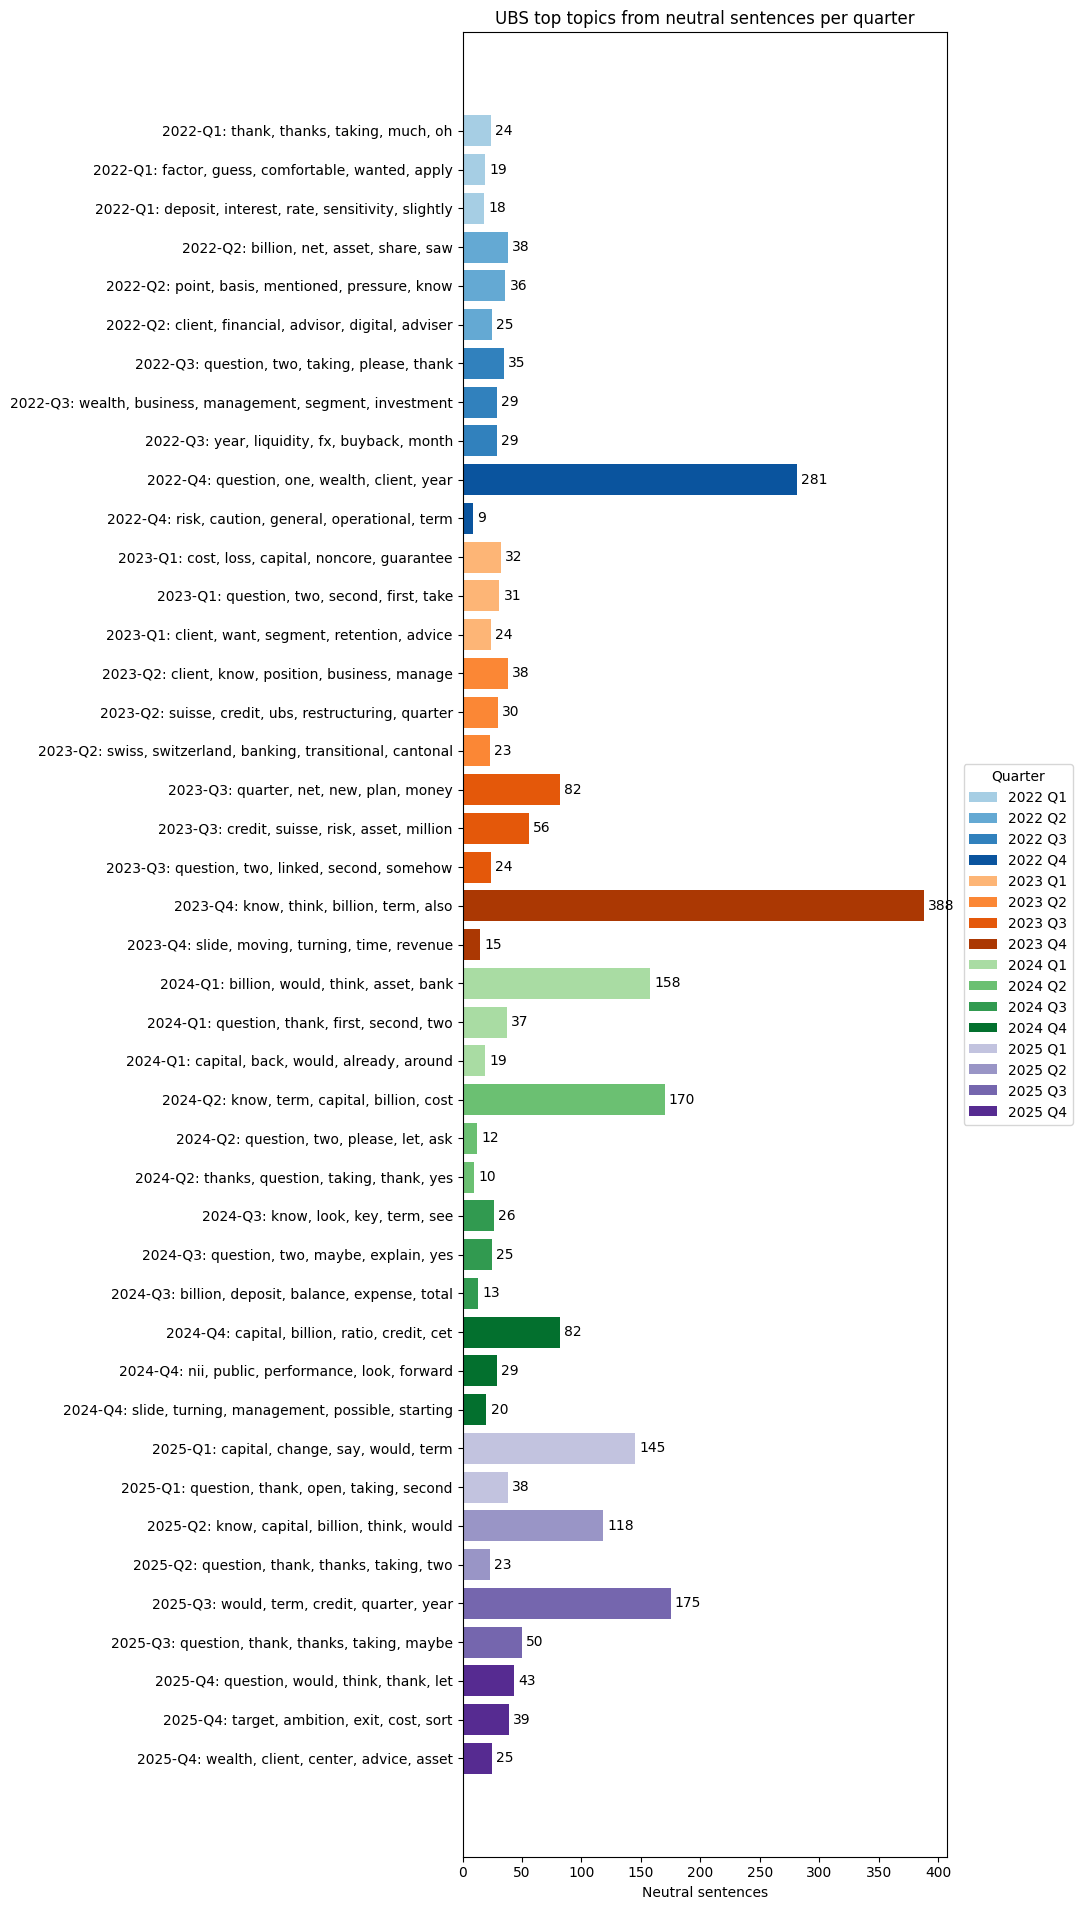

In [445]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_top_topics_single_figure(top_topics, bank=""):
    df = top_topics_neutral.copy()
    df["year"] = df["quarter"].str[:4]
    df["q"] = df["quarter"].str[-1].astype(int)

    # Chronological order, largest topic first within each quarter
    df = df.sort_values(["year", "q", "count"], ascending=[True, True, False]).reset_index(drop=True)

    base_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Reds", "Greys"]
    years = sorted(df["year"].unique())
    year_cmap = {y: plt.get_cmap(base_cmaps[i % len(base_cmaps)]) for i, y in enumerate(years)}
    # Q1 lightest -> Q4 darkest
    shade = {1: 0.35, 2: 0.52, 3: 0.69, 4: 0.86}

    colours = [year_cmap[r.year](shade[r.q]) for r in df.itertuples()]


    labels = [f"{r.quarter}: {r.keywords}" for r in df.itertuples()]

    fig, ax = plt.subplots(figsize=(11, 0.4 * len(df) + 2))
    bars = ax.barh(range(len(df)), df["count"], color=colours)
    ax.bar_label(bars, padding=3)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Neutral sentences")

    handles = [
        Patch(facecolor=year_cmap[y](shade[q]), label=f"{y} Q{q}")
        for y in years
        for q in sorted(df.loc[df["year"] == y, "q"].unique())
    ]
    ax.legend(handles=handles, title="Quarter", loc="center left",
              bbox_to_anchor=(1.02, 0.5))
    ax.set_title(f"{bank} top topics from neutral sentences per quarter".strip())
    fig.tight_layout()
    # save figure in bank folder
    plt.savefig(f"{results_folder}/neutral_sentence_topics_by_quarter_for_{bank_name}.png")

    plt.show()


plot_top_topics_single_figure(top_topics_neutral, bank=bank_name)

# Compare Models Predictions (mathematically)

### Map data to align (at end after analysis)

In [446]:
# for column "FBT_Main_Sentiment" map Positive as positive, Negative as negative and Neutral as neutral
data["FBT_Main_Sentiment"] = data["FBT_Main_Sentiment"].map({
    "Positive": "positive",
    "Negative": "negative",
    "Neutral": "neutral"
})

# for column "RBT_main_sentiment" map RBT_positive as positive, RBT_negative as negative and RBT_neutral as neutral
data["RBT_main_sentiment"] = data["RBT_main_sentiment"].map({
    "RBT_positive": "positive",
    "RBT_negative": "negative",
    "RBT_neutral": "neutral"
})

In [447]:
from sklearn.metrics import cohen_kappa_score
for c in ['main_sentiment', 'FBT_Main_Sentiment', 'RBT_main_sentiment']:
    print(c, data[c].map(type).value_counts().to_dict())
    print(data[c].head(3).tolist())

main_sentiment {<class 'str'>: 8217}
['neutral', 'negative', 'neutral']
FBT_Main_Sentiment {<class 'str'>: 8217}
['neutral', 'negative', 'neutral']
RBT_main_sentiment {<class 'str'>: 8217}
['positive', 'neutral', 'positive']


In [448]:
def to_label(x):
    if isinstance(x, dict):
        x = x.get('label')
    if isinstance(x, (list, tuple)) and x:      # e.g. [{'label': ..., 'score': ...}]
        x = x[0].get('label') if isinstance(x[0], dict) else x[0]
    return str(x).lower().replace('rbt_', '').strip() if x is not None else None

cols = ['main_sentiment', 'FBT_Main_Sentiment', 'RBT_main_sentiment']
clean = data[cols].map(to_label).dropna()

from itertools import combinations
for a, b in combinations(cols, 2):
    print(a, 'vs', b, cohen_kappa_score(clean[a], clean[b]))

main_sentiment vs FBT_Main_Sentiment 0.6694400024967773
main_sentiment vs RBT_main_sentiment 0.501141529084622
FBT_Main_Sentiment vs RBT_main_sentiment 0.5664916334103479


A score above 0.6 suggests substantial agreement from the models

# Check run times

In [449]:
# End timer and print elapsed time in minutes to 2 significant figures
end_time = time.time()
print("Elapsed time: ", round((end_time - start_time)/60, 2), "minutes")

Elapsed time:  10.83 minutes
